In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
#Import plotting means 
import matplotlib.pyplot as plt
import seaborn as sns
import kaleido
import plotly.graph_objects as go


In [2]:
master = pd.read_csv("..\MASTER\Master.csv")

<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31620\1912846909.py:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
  master = pd.read_csv("..\MASTER\Master.csv")


In [3]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 48 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Unnamed: 0                                                           3150 non-null   int64  
 1   Country Code                                                         3150 non-null   object 
 2   Country Name                                                         3150 non-null   object 
 3   Year                                                                 3150 non-null   int64  
 4   Access to electricity (% of population)                              3150 non-null   float64
 5   Adjusted savings: gross savings (% of GNI)                           3150 non-null   float64
 6   Agriculture                                                          3150 non-null   float64
 7   Capita

In [4]:
master.columns

Index(['Unnamed: 0', 'Country Code', 'Country Name', 'Year',
       'Access to electricity (% of population)',
       'Adjusted savings: gross savings (% of GNI)', 'Agriculture',
       'Capital depreciation rate', 'Clientelism index',
       'Death rates, crude per 1000 people',
       'Domestic credit to private sector (% of GDP)',
       'Economic Complexity Index', 'GDP per capita (constant prices, PPP)',
       'Government revenue',
       'Gross fixed capital formation, all, Constant prices, Percent of GDP',
       'Human capital index', 'Industry',
       'Inflation, consumer prices (annual %)', 'Landlocked',
       'Lending interest rate (%)', 'Life expectancy at birth, total (years)',
       'Manufacturing', 'Mineral rents (% of GDP)',
       'Mobile cellular subscriptions (per 100 people)',
       'Natural gas rents (% of GDP)', 'Oil rents (% of GDP)',
       'Political corruption index', 'Political stability — estimate',
       'Primary net lending, General government, Perce

In [5]:
master['Total_Production_Value_Per_Capita'] = master['Total_Production_Value'] / master['Population']
master['Total_Reserves_Value_Per_Capita'] = master['Total_Reserves_Value'] / master['Population']

In [6]:
country_number = master['Country Name'].nunique()
year_number = master['Year'].nunique()

In [7]:
f'We have a master data set with {country_number} countries and {year_number} years'

'We have a master data set with 126 countries and 25 years'

In [8]:
#master['Income1995'].unique()

In [9]:
#master['Country Name'][master['Income1995'] == 'High-income countries'].unique()

UAE, Kuwait, Qatar

In [10]:
#master['Country Name'][master['Income1995'] == 'Upper-middle-income countries'].unique()

Thematic Grouping

In [11]:
variable_groups = {
    'identifiers': [
        'Country Code', 'Country Name', 'Year'
    ],

        'economic_complexity_index': [
        'Economic Complexity Index'
    ],
    
    'resource_dependence': [
        'Oil rents (% of GDP)',
        'Natural gas rents (% of GDP)',
        'Mineral rents (% of GDP)',
        'Total natural resources rents (% of GDP)',
        'Total_Production',
        'Total_Reserves',
        'Total_Production_Value',
        'Total_Reserves_Value',
        'Total_Production_Value_Per_Capita',
        'Total_Reserves_Value_Per_Capita',
        'Hydrocarbons_Dominant',
        'Subsoil_Metals_Dominant',
        'Precious_Metals_Dominant'
    ],
    
    'economic_structure': [
        'Trade (% of GDP)',
        'Agriculture',
        'Industry',
        'Manufacturing',
        'Services'
    ],
    
    'macroeconomic_indicators': [
        'GDP per capita (constant prices, PPP)',
        'Inflation, consumer prices (annual %)',
        'Share of consumption in GDP',
        'Share of investment in GDP',
        'Share of government spending in GDP',
        'Gross fixed capital formation, all, Constant prices, Percent of GDP',
        'Capital depreciation rate'
    ],
    
    'fiscal_financial': [
        'Government revenue',
        'Primary net lending, General government, Percent of GDP',
        'Adjusted savings: gross savings (% of GNI)',
        'Domestic credit to private sector (% of GDP)',
        'Lending interest rate (%)',
        'Real interest rate (%)',
        'Use of IMF credit (DOD, current US$)'
    ],
    
    'governance_institutions': [
        'Rule of law index',
        'Political corruption index',
        'Clientelism index',
        'Property rights',
        'Political stability — estimate'
    ],
    
    'human_capital_development': [
        'Human capital index',
        'Life expectancy at birth, total (years)',
        'Death rates, crude per 1000 people'
    ],
    
    'infrastructure_technology': [
        'Access to electricity (% of population)',
        'Mobile cellular subscriptions (per 100 people)'
    ],
    
    'structural_characteristics': [
        'Landlocked',
        'Urban population (% of total population)',
        'Population'
    ]
}

In [12]:
def create_descriptive_table(df, variable_groups, exclude_groups=['identifiers']):
    """
    Create descriptive statistics tables for each variable group
    
    Parameters:
    - df: your master dataframe
    - variable_groups: dictionary with theme names as keys and variable lists as values
    - exclude_groups: list of group names to skip
    """
    
    all_tables = {}
    
    for group_name, variables in variable_groups.items():
        if group_name in exclude_groups:
            continue
        
        # Get variables that exist in the dataframe
        existing_vars = [v for v in variables if v in df.columns]
        
        if not existing_vars:
            continue
        
        # Calculate statistics
        stats_data = []
        
        for var in existing_vars:
            stats_data.append({
                'Variable': var,
                'Mean': df[var].mean(),
                'Std': df[var].std(),
                'Median': df[var].median(),
                'Q1': df[var].quantile(0.25),
                'Q3': df[var].quantile(0.75),
                'N': df[var].count()
            })
        
        # Create dataframe for this group
        group_table = pd.DataFrame(stats_data)
        
        # Round numeric columns
        numeric_cols = ['Mean', 'Std', 'Median', 'Q1', 'Q3']
        group_table[numeric_cols] = group_table[numeric_cols].round(3)
        
        all_tables[group_name] = group_table
        
        # Display the table
        print(f"\n{'='*80}")
        print(f"{group_name.upper().replace('_', ' ')}")
        print(f"{'='*80}")
        print(group_table.to_string(index=False))
        print()
    
    return all_tables

# Usage
descriptive_tables = create_descriptive_table(master, variable_groups)


ECONOMIC COMPLEXITY INDEX
                 Variable  Mean   Std  Median     Q1    Q3    N
Economic Complexity Index -0.07 1.024  -0.209 -0.832 0.586 3150


RESOURCE DEPENDENCE
                                Variable         Mean          Std       Median           Q1           Q3    N
                    Oil rents (% of GDP) 5.318000e+00 1.137100e+01 1.990000e-01 0.000000e+00 3.333000e+00 3150
            Natural gas rents (% of GDP) 6.530000e-01 1.677000e+00 2.100000e-02 0.000000e+00 4.200000e-01 3150
                Mineral rents (% of GDP) 8.590000e-01 2.266000e+00 4.600000e-02 0.000000e+00 5.170000e-01 3150
Total natural resources rents (% of GDP) 8.948000e+00 1.222700e+01 3.580000e+00 8.070000e-01 1.224300e+01 3150
                        Total_Production 1.065785e+09 3.348657e+09 1.460838e+07 9.092590e+04 6.990435e+08 3150
                          Total_Reserves 1.168245e+09 4.385390e+09 0.000000e+00 0.000000e+00 3.465148e+08 3150
                  Total_Production_Value 1.476

In [13]:
# Calculate statistics
eci_stats = master.groupby('Year')['Economic Complexity Index'].agg([
    ('Mean', 'mean'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75))
]).reset_index()

fig = go.Figure()

# Add interquartile range as shaded area
fig.add_trace(go.Scatter(
    x=eci_stats['Year'].tolist() + eci_stats['Year'].tolist()[::-1],
    y=eci_stats['Q3'].tolist() + eci_stats['Q1'].tolist()[::-1],
    fill='toself',
    fillcolor='rgba(44, 62, 80, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=True,
    name='Interquartile Range',
    hoverinfo='skip'
))

# Add mean line
fig.add_trace(go.Scatter(
    x=eci_stats['Year'],
    y=eci_stats['Mean'],
    mode='lines+markers',
    line=dict(color='#2C3E50', width=2.5),
    marker=dict(size=6, color='#2C3E50'),
    name='Mean'
))

fig.update_layout(
    title={
        'text': 'Evolution of Economic Complexity Index',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16, 'color': '#2C3E50'}
    },
    xaxis_title='Year',
    yaxis_title='Economic Complexity Index',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial, sans-serif", size=12, color='#2C3E50'),
    xaxis=dict(
        showgrid=True,
        gridcolor='#E5E5E5',
        showline=True,
        linecolor='#2C3E50',
        linewidth=1
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#E5E5E5',
        showline=True,
        linecolor='#2C3E50',
        linewidth=1
    ),
    hovermode='x unified',
    width=900,
    height=500,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='#E5E5E5',
        borderwidth=1
    )
)

fig.show()

Plot is not useful because ECI is normalized each year. 

## Heatmap

In [14]:
import plotly.graph_objects as go
import pandas as pd

def create_eci_correlation_heatmap(df, variable_groups, exclude_groups=['identifiers', 'economic_complexity_index']):
    """
    Create a heatmap showing ECI correlation with all variables, grouped by theme
    """
    
    # Collect all variables with their themes and correlations
    data_list = []
    
    for group_name, vars_list in variable_groups.items():
        if group_name in exclude_groups:
            continue
        
        existing_vars = [v for v in vars_list if v in df.columns]
        
        for var in existing_vars:
            # Calculate correlation
            corr = df[['Economic Complexity Index', var]].corr().iloc[0, 1]
            
            data_list.append({
                'Theme': group_name.replace('_', ' ').title(),
                'Variable': var,
                'Correlation': corr
            })
    
    # Create dataframe
    corr_df = pd.DataFrame(data_list)
    
    # Sort by theme first, then by correlation within each theme
    corr_df = corr_df.sort_values(['Theme', 'Correlation'], ascending=[True, False])
    
    # Reset index to get proper ordering
    corr_df = corr_df.reset_index(drop=True)
    
    # Create the heatmap data
    z_values = corr_df['Correlation'].values.reshape(-1, 1)
    y_labels = corr_df['Variable'].tolist()
    
    # Create heatmap
    fig = go.Figure(data=go.Heatmap(
        z=z_values,
        y=y_labels,
        x=['Correlation with ECI'],
        colorscale=[
            [0, '#D73027'],      # Strong negative (red)
            [0.25, '#FC8D59'],   # Moderate negative (orange)
            [0.5, '#FFFFBF'],    # Near zero (light yellow)
            [0.75, '#91BFDB'],   # Moderate positive (light blue)
            [1, '#4575B4']       # Strong positive (dark blue)
        ],
        zmid=0,
        text=z_values,
        texttemplate='%{text:.3f}',
        textfont={"size": 9},
        colorbar=dict(
            title="Correlation",
            tickmode="linear",
            tick0=-1,
            dtick=0.25,
            thickness=15,
            len=0.7
        ),
        hovertemplate='<b>%{y}</b><br>Correlation: %{z:.3f}<extra></extra>'
    ))
    
    # Find theme boundaries and create separators
    theme_boundaries = []
    theme_midpoints = []
    theme_labels = []
    
    current_theme = None
    theme_start = 0
    
    for idx, row in corr_df.iterrows():
        if current_theme != row['Theme']:
            if current_theme is not None:
                # Add boundary line
                theme_boundaries.append(idx - 0.5)
                # Calculate midpoint for previous theme
                theme_midpoints.append((theme_start + idx - 1) / 2)
                theme_labels.append(current_theme)
            
            current_theme = row['Theme']
            theme_start = idx
    
    # Add last theme
    if current_theme is not None:
        theme_midpoints.append((theme_start + len(corr_df) - 1) / 2)
        theme_labels.append(current_theme)
    
    # Update layout
    fig.update_layout(
        title={
            'text': 'Economic Complexity Index - Correlation Matrix by Theme',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 16, 'color': '#2C3E50', 'family': 'Arial, sans-serif'}
        },
        xaxis=dict(
            side='top',
            showgrid=False,
            showline=True,
            linecolor='#2C3E50',
            linewidth=1
        ),
        yaxis=dict(
            showgrid=False,
            showline=True,
            linecolor='#2C3E50',
            linewidth=1,
            tickfont=dict(size=9),
            autorange='reversed'  # This ensures top to bottom ordering
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        font=dict(family="Arial, sans-serif", size=11, color='#2C3E50'),
        height=max(800, len(y_labels) * 18),
        width=900,
        margin=dict(l=350, r=150, t=100, b=50)
    )
    
    # Add horizontal lines to separate themes
    shapes = []
    for boundary in theme_boundaries:
        shapes.append(dict(
            type='line',
            x0=-0.55, x1=0.55,
            y0=boundary, y1=boundary,
            line=dict(color='#2C3E50', width=2),
            xref='x',
            yref='y'
        ))
    
    fig.update_layout(shapes=shapes)
    
    # Add theme labels on the left side
    annotations = []
    for label, midpoint in zip(theme_labels, theme_midpoints):
        annotations.append(dict(
            x=-0.75,
            y=midpoint,
            text=f'<b>{label}</b>',
            showarrow=False,
            xanchor='right',
            yanchor='middle',
            font=dict(size=11, color='#2C3E50', family='Arial, sans-serif'),
            xref='x',
            yref='y',
            textangle=0
        ))
    
    fig.update_layout(annotations=annotations)
    
    return fig, corr_df

# Create the heatmap
fig, corr_data = create_eci_correlation_heatmap(master, variable_groups)
fig.show()

# Print summary statistics
print("\nCorrelation Summary by Theme:")
print(corr_data.groupby('Theme')['Correlation'].agg(['mean', 'min', 'max']).round(3))

print("\n\nTop 10 Positive Correlations with ECI:")
print(corr_data.nlargest(10, 'Correlation')[['Variable', 'Theme', 'Correlation']].to_string(index=False))

print("\n\nTop 10 Negative Correlations with ECI:")
print(corr_data.nsmallest(10, 'Correlation')[['Variable', 'Theme', 'Correlation']].to_string(index=False))

# Save
fig.write_html(r'..\\figures\\summary_stats\\eci_correlation_heatmap.html')
fig.write_image('..\\figures\\summary_stats\\eci_correlation_heatmap.png', width=900, height=1400, scale=2)


Correlation Summary by Theme:
                             mean    min    max
Theme                                          
Economic Structure          0.105 -0.552  0.631
Fiscal Financial            0.122 -0.297  0.672
Governance Institutions     0.088 -0.675  0.668
Human Capital Development   0.457 -0.048  0.739
Infrastructure Technology   0.481  0.349  0.613
Macroeconomic Indicators    0.110 -0.223  0.597
Resource Dependence        -0.061 -0.472  0.195
Structural Characteristics  0.081 -0.072  0.205


Top 10 Positive Correlations with ECI:
                                    Variable                     Theme  Correlation
                         Human capital index Human Capital Development     0.739458
     Life expectancy at birth, total (years) Human Capital Development     0.678240
Domestic credit to private sector (% of GDP)          Fiscal Financial     0.672480
                           Rule of law index   Governance Institutions     0.667558
                            

# High Natural Resource Countries

In [15]:
#high_resource_countries = master[
#    ((master['Total natural resources rents (% of GDP)'] >= 5) & 
#     (master['Year'] == 1995) & 
#     (master['Income1995'] != 'High-income countries')) |
#    ((master['Country Name'].isin(['United Arab Emirates', 'Kuwait', 'Qatar'])) & 
#     (master['Year'] == 1995))
#]

In [16]:
high_resource_countries = master[master['Country Code'].isin(['AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
       'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
       'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
       'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
       'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
       'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE'])]

In [17]:
high_resource_countries['Country Name'].unique()

array(['Angola', 'United Arab Emirates', 'Azerbaijan', 'Burkina Faso',
       'Bahrain', 'Bolivia', 'Chile', "Cote d'Ivoire", 'Cameroon',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Algeria', 'Ecuador',
       'Egypt, Arab Rep.', 'Ethiopia', 'Gabon', 'Ghana', 'Guinea',
       'Equatorial Guinea', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq',
       'Kazakhstan', 'Kenya', 'Kuwait', 'Lao PDR', 'Liberia', 'Libya',
       'Madagascar', 'Mali', 'Myanmar', 'Mongolia', 'Mozambique',
       'Malawi', 'Malaysia', 'Niger', 'Nigeria', 'Oman',
       'Papua New Guinea', 'Qatar', 'Russian Federation', 'Rwanda',
       'Saudi Arabia', 'Chad', 'Togo', 'Trinidad and Tobago', 'Tanzania',
       'Uganda', 'Uzbekistan', 'Venezuela, RB', 'Viet Nam', 'Yemen, Rep.',
       'Zambia', 'Zimbabwe'], dtype=object)

In [18]:
high_resource_countries['Country Name'].nunique()

54

In [19]:
high_resource_countries['Country Code'].unique()

array(['AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
       'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
       'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
       'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
       'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
       'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE'],
      dtype=object)

In [20]:
high_resource_countries_df = master[master['Country Code'].isin(['AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
       'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
       'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
       'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
       'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
       'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE'])]

In [ ]:
high_resource_countries_df.to_csv("C:/Users/emili/OneDrive/Documentos/LSE MPA DSPP/AT 2025/Capstone/Master Data/high_resource_countries.csv")

OSError: Cannot save file into a non-existent directory: 'C:\Users\emili\OneDrive\Documentos\LSE MPA DSPP\AT 2025\Capstone\Master Data'

In [ ]:
cluster_1995 = pd.read_csv("C:/Users/emili/OneDrive/Documentos/LSE MPA DSPP/AT 2025/Capstone/Master Data/clusters1995.csv")

In [ ]:
cluster_1995=cluster_1995[['Country Code', 'Cluster']]

In [ ]:
high_resource_countries_df = high_resource_countries_df.merge(cluster_1995, on=['Country Code'], how='left')

In [ ]:
natural_resource_country_number = high_resource_countries_df['Country Name'].nunique()
natural_resource_year_number = high_resource_countries_df['Year'].nunique()

In [ ]:
f'We have a master data set with {natural_resource_country_number} countries and {natural_resource_year_number} years'

'We have a master data set with 54 countries and 25 years'

In [ ]:
descriptive_tables = create_descriptive_table(high_resource_countries_df, variable_groups)


ECONOMIC COMPLEXITY INDEX
                 Variable  Mean  Std  Median    Q1     Q3    N
Economic Complexity Index -0.76 0.67  -0.804 -1.22 -0.343 1350


RESOURCE DEPENDENCE
                                Variable         Mean          Std       Median           Q1           Q3    N
                    Oil rents (% of GDP) 1.128900e+01 1.518600e+01 3.425000e+00 0.000000e+00 1.879700e+01 1350
            Natural gas rents (% of GDP) 1.161000e+00 2.118000e+00 1.710000e-01 0.000000e+00 1.535000e+00 1350
                Mineral rents (% of GDP) 1.263000e+00 2.794000e+00 5.500000e-02 0.000000e+00 8.390000e-01 1350
Total natural resources rents (% of GDP) 1.791300e+01 1.364700e+01 1.359600e+01 7.513000e+00 2.441000e+01 1350
                        Total_Production 1.274763e+09 3.473349e+09 8.866838e+07 9.935182e+04 1.231296e+09 1350
                          Total_Reserves 2.312301e+09 6.420694e+09 7.841884e+05 0.000000e+00 1.312111e+09 1350
                  Total_Production_Value 1.70483

In [ ]:
# Create the heatmap
fig, corr_data = create_eci_correlation_heatmap(high_resource_countries_df, variable_groups)
fig.show()

# Print summary statistics
print("\nCorrelation Summary by Theme:")
print(corr_data.groupby('Theme')['Correlation'].agg(['mean', 'min', 'max']).round(3))

print("\n\nTop 10 Positive Correlations with ECI:")
print(corr_data.nlargest(10, 'Correlation')[['Variable', 'Theme', 'Correlation']].to_string(index=False))

print("\n\nTop 10 Negative Correlations with ECI:")
print(corr_data.nsmallest(10, 'Correlation')[['Variable', 'Theme', 'Correlation']].to_string(index=False))

fig.write_html(r'..\\figures\\summary_stats\\eci_correlation_heatmap.html')


Correlation Summary by Theme:
                             mean    min    max
Theme                                          
Economic Structure          0.118 -0.309  0.327
Fiscal Financial            0.128 -0.278  0.582
Governance Institutions     0.010 -0.393  0.316
Human Capital Development   0.211 -0.387  0.512
Infrastructure Technology   0.405  0.314  0.497
Macroeconomic Indicators    0.060 -0.216  0.430
Resource Dependence         0.136 -0.136  0.433
Structural Characteristics  0.089 -0.066  0.221


Top 10 Positive Correlations with ECI:
                                    Variable                     Theme  Correlation
Domestic credit to private sector (% of GDP)          Fiscal Financial     0.581617
                         Human capital index Human Capital Development     0.512310
     Life expectancy at birth, total (years) Human Capital Development     0.507606
     Access to electricity (% of population) Infrastructure Technology     0.497311
                            

# ECI evolution resource rich vs non resource rich (rest of the world, non selected)

In [ ]:
# Compare trajectories
fig = go.Figure()

# high resource countries
high_resource = high_resource_countries_df.groupby('Year')['Economic Complexity Index'].mean()
fig.add_trace(go.Scatter(x=high_resource.index, y=high_resource.values, 
                         mode='lines+markers', name='High Resource Countries',
                         line=dict(color='#E74C3C', width=2.5)))

# non resource countries
non_resource = master[~master['Country Name'].isin(high_resource_countries_df)].groupby('Year')['Economic Complexity Index'].mean()
fig.add_trace(go.Scatter(x=non_resource.index, y=non_resource.values,
                         mode='lines+markers', name='Other Countries',
                         line=dict(color='#3498DB', width=2.5)))

fig.update_layout(title='ECI Evolution: Resource-Rich vs Other Countries',
                  xaxis_title='Year', yaxis_title='Average ECI',
                  plot_bgcolor='white', paper_bgcolor='white')
fig.show()
fig.write_html(r'..\\figures\\summary_stats\\eci_evolution_resource_rich_vs_other.html')

# Scatter: Resource Dependence vs ECI (with country labels)

In [ ]:
snapshot = high_resource_countries_df[high_resource_countries_df['Year'] == 2015].copy()
# Calculate percentiles to determine appropriate range
p90 = snapshot['Total_Production_Value_Per_Capita'].quantile(0.90)
p95 = snapshot['Total_Production_Value_Per_Capita'].quantile(0.95)

print(f"90th percentile: {p90:,.0f}")
print(f"95th percentile: {p95:,.0f}")


# Take a snapshot year (e.g., 2015 or latest available)
snapshot = high_resource_countries_df[high_resource_countries_df['Year'] == 2015].copy()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=snapshot['Total_Production_Value_Per_Capita'],
    y=snapshot['Economic Complexity Index'],
    mode='markers+text',
    text=snapshot['Country Name'],
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(size=8, color='#2C3E50', opacity=0.6),
    hovertemplate='<b>%{text}</b><br>Resource Rents: %{x:.1f}%<br>ECI: %{y:.2f}<extra></extra>'
))

fig.update_layout(
    title='Resource Dependence (Production) vs Economic Complexity (2015)',
    xaxis_title='Total Production Value Per Capita',
    yaxis_title='Economic Complexity Index',
    xaxis=dict(range=[0, p90]),  # Show up to 90th percentile
    plot_bgcolor='white', paper_bgcolor='white',
    height=700, width=1000
)
fig.show()
fig.write_html(r'..\\figures\\summary_stats\\resource dependence vs economic complexity Production.html')

90th percentile: 2,666
95th percentile: 4,492


# Summary Statistics by Resource Type

In [ ]:
# Compare key indicators across resource types
resource_comparison = []

for resource_type in ['Hydrocarbons_Dominant', 'Subsoil_Metals_Dominant', 'Precious_Metals_Dominant']:
    subset = high_resource_countries_df[high_resource_countries_df[resource_type] == 1]
    
    resource_comparison.append({
        'Resource Type': resource_type.replace('_', ' ').replace(' Dominant', ''),
        'N Countries': subset['Country Name'].nunique(),
        'Avg ECI': subset['Economic Complexity Index'].mean(),
        'Avg Manufacturing %': subset['Manufacturing'].mean(),
        'Avg Production Value Per Capita': subset['Total_Production_Value_Per_Capita'].mean(),
        'Avg GDP per capita': subset['GDP per capita (constant prices, PPP)'].mean()
    })

comparison_table = pd.DataFrame(resource_comparison)
print(comparison_table.round(2))

     Resource Type  N Countries  Avg ECI  Avg Manufacturing %  \
0     Hydrocarbons           35    -0.64                12.51   
1   Subsoil Metals           13    -0.98                11.48   
2  Precious Metals           18    -0.88                 9.40   

   Avg Production Value Per Capita  Avg GDP per capita  
0                          2594.16            20350.48  
1                           353.21             6739.99  
2                            40.56             2269.27  


In [ ]:
comparison_table = pd.DataFrame(resource_comparison)

styled_table = (comparison_table.style
    .format({
        'N Countries': '{:.0f}',
        'Avg ECI': '{:.2f}',
        'Avg Manufacturing %': '{:.1f}%',
        'Avg Production Value Per Capita': '{:.0f}',
        'Avg GDP per capita': '${:,.0f}'
    })
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2C5F8D'), 
                                      ('color', 'white'),
                                      ('font-weight', 'bold'),
                                      ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
    ])
    .hide(axis='index')
)

styled_table

Resource Type,N Countries,Avg ECI,Avg Manufacturing %,Avg Production Value Per Capita,Avg GDP per capita
Hydrocarbons,35,-0.64,12.5%,2594,"$20,350"
Subsoil Metals,13,-0.98,11.5%,353,"$6,740"
Precious Metals,18,-0.88,9.4%,41,"$2,269"


# Winners vs Losers Table

In [ ]:
# Add percentile ranks for initial and final years
initial_year = high_resource_countries_df['Year'].min()
final_year = high_resource_countries_df['Year'].max()

initial_eci = high_resource_countries_df[high_resource_countries_df['Year'] == initial_year].copy()
final_eci = high_resource_countries_df[high_resource_countries_df['Year'] == final_year].copy()

initial_eci['ECI_Percentile_Initial'] = initial_eci['Economic Complexity Index'].rank(pct=True) * 100
final_eci['ECI_Percentile_Final'] = final_eci['Economic Complexity Index'].rank(pct=True) * 100

eci_change = initial_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Initial']].merge(
    final_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Final']],
    on='Country Name',
    suffixes=('_Initial', '_Final')
)

eci_change['ECI_Change'] = eci_change['Economic Complexity Index_Final'] - eci_change['Economic Complexity Index_Initial']

# Sort by absolute ECI change
eci_change = eci_change.sort_values('ECI_Change', ascending=False)

# Clean up column names for display
eci_change_display = eci_change[[
    'Country Name', 
    'ECI_Change',
    'ECI_Percentile_Initial',
    'ECI_Percentile_Final'
]].copy()

# Round percentiles to no decimals
eci_change_display['ECI_Percentile_Initial'] = eci_change_display['ECI_Percentile_Initial'].round(0).astype(int)
eci_change_display['ECI_Percentile_Final'] = eci_change_display['ECI_Percentile_Final'].round(0).astype(int)

eci_change_display.columns = [
    'Country', 
    'ECI Change',
    'Percentile (1995)',
    'Percentile (2019)'
]

print("=" * 80)
print(f"Top 10 ECI Improvers (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("=" * 80)
print(eci_change_display.head(10).to_string(index=False))

print("\n" + "=" * 80)
print(f"Top 10 ECI Decliners (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("=" * 80)
print(eci_change_display.tail(10).to_string(index=False))

Top 10 ECI Improvers (Resource-Rich Countries, 1995-2019)
           Country  ECI Change  Percentile (1995)  Percentile (2019)
  Papua New Guinea       1.011                  2                 15
          Viet Nam       0.985                 31                 83
           Bahrain       0.903                 63                 96
          Malaysia       0.876                 96                100
Iran, Islamic Rep.       0.855                 41                 87
            Angola       0.710                  7                 30
            Kuwait       0.676                 78                 94
             Qatar       0.660                 54                 85
           Nigeria       0.609                  6                  7
           Lao PDR       0.552                 15                 59

Top 10 ECI Decliners (Resource-Rich Countries, 1995-2019)
      Country  ECI Change  Percentile (1995)  Percentile (2019)
      Liberia      -0.402                 61                

In [ ]:
# Add percentile ranks for initial and final years
initial_year = high_resource_countries_df['Year'].min()
final_year = high_resource_countries_df['Year'].max()

initial_eci = high_resource_countries_df[high_resource_countries_df['Year'] == initial_year].copy()
final_eci = high_resource_countries_df[high_resource_countries_df['Year'] == final_year].copy()

initial_eci['ECI_Percentile_Initial'] = initial_eci['Economic Complexity Index'].rank(pct=True) * 100
final_eci['ECI_Percentile_Final'] = final_eci['Economic Complexity Index'].rank(pct=True) * 100

eci_change = initial_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Initial']].merge(
    final_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Final']],
    on='Country Name',
    suffixes=('_Initial', '_Final')
)

eci_change['ECI_Change'] = eci_change['Economic Complexity Index_Final'] - eci_change['Economic Complexity Index_Initial']

# Sort by absolute ECI change
eci_change = eci_change.sort_values('ECI_Change', ascending=False)

# Prepare display dataframes
eci_improvers = eci_change.head(10).copy()
eci_decliners = eci_change.tail(10).copy()

# Format the dataframes
for df in [eci_improvers, eci_decliners]:
    df['ECI_Change'] = df['ECI_Change'].round(3)
    df['ECI_Percentile_Initial'] = df['ECI_Percentile_Initial'].round(0).astype(int)
    df['ECI_Percentile_Final'] = df['ECI_Percentile_Final'].round(0).astype(int)

# Rename columns
eci_improvers = eci_improvers.rename(columns={
    'Country Name': 'Country',
    'ECI_Change': 'ECI Change',
    'ECI_Percentile_Initial': f'Percentile ({int(initial_year)})',
    'ECI_Percentile_Final': f'Percentile ({int(final_year)})'
})

eci_decliners = eci_decliners.rename(columns={
    'Country Name': 'Country',
    'ECI_Change': 'ECI Change',
    'ECI_Percentile_Initial': f'Percentile ({int(initial_year)})',
    'ECI_Percentile_Final': f'Percentile ({int(final_year)})'
})

# Select only the columns we want
display_cols = ['Country', 'ECI Change', f'Percentile ({int(initial_year)})', f'Percentile ({int(final_year)})']
eci_improvers = eci_improvers[display_cols]
eci_decliners = eci_decliners[display_cols]

# Create HTML with custom styling
html_template = """
<!DOCTYPE html>
<html>
<head>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            margin: 40px;
            background-color: #f5f5f5;
        }}
        h2 {{
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
            margin-top: 40px;
        }}
        table {{
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
            background-color: white;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }}
        th {{
            background-color: #3498db;
            color: white;
            text-align: left;
            padding: 12px;
            font-weight: 600;
        }}
        td {{
            padding: 10px 12px;
            border-bottom: 1px solid #ddd;
        }}
        tr:hover {{
            background-color: #f8f9fa;
        }}
        tr:last-child td {{
            border-bottom: none;
        }}
        .positive {{
            color: #27ae60;
            font-weight: 600;
        }}
        .negative {{
            color: #e74c3c;
            font-weight: 600;
        }}
        .country {{
            font-weight: 600;
            color: #2c3e50;
        }}
    </style>
</head>
<body>
    <h2>Top 10 ECI Improvers (Resource-Rich Countries, {start_year}-{end_year})</h2>
    {improvers_table}
    
    <h2>Top 10 ECI Decliners (Resource-Rich Countries, {start_year}-{end_year})</h2>
    {decliners_table}
</body>
</html>
"""

# Convert dataframes to HTML
improvers_html = eci_improvers.to_html(
    classes='data-table',
    escape=False,
    index=False,
    float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else x
)

decliners_html = eci_decliners.to_html(
    classes='data-table',
    escape=False,
    index=False,
    float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else x
)

# Combine into final HTML
final_html = html_template.format(
    start_year=int(initial_year),
    end_year=int(final_year),
    improvers_table=improvers_html,
    decliners_table=decliners_html
)

# Save to file
with open('eci_changes_percentiles.html', 'w', encoding='utf-8') as f:
    f.write(final_html)

print("\n" + "="*80)
print("HTML TABLES CREATED")
print("="*80)
print("Saved to: eci_changes_percentiles.html")
print(f"\nTop improvers: {len(eci_improvers)} countries")
print(f"Top decliners: {len(eci_decliners)} countries")
print(f"\nLargest improvement: {eci_improvers['ECI Change'].iloc[0]:.3f} ({eci_improvers['Country'].iloc[0]})")
print(f"Largest decline: {eci_decliners['ECI Change'].iloc[-1]:.3f} ({eci_decliners['Country'].iloc[-1]})")

# Also print to console
print("\n" + "="*80)
print(f"Top 10 ECI Improvers (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("="*80)
print(eci_improvers.to_string(index=False))

print("\n" + "="*80)
print(f"Top 10 ECI Decliners (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("="*80)
print(eci_decliners.to_string(index=False))


HTML TABLES CREATED
Saved to: eci_changes_percentiles.html

Top improvers: 10 countries
Top decliners: 10 countries

Largest improvement: 1.011 (Papua New Guinea)
Largest decline: -1.560 (Venezuela, RB)

Top 10 ECI Improvers (Resource-Rich Countries, 1995-2019)
           Country  ECI Change  Percentile (1995)  Percentile (2019)
  Papua New Guinea       1.011                  2                 15
          Viet Nam       0.985                 31                 83
           Bahrain       0.903                 63                 96
          Malaysia       0.876                 96                100
Iran, Islamic Rep.       0.855                 41                 87
            Angola       0.710                  7                 30
            Kuwait       0.676                 78                 94
             Qatar       0.660                 54                 85
           Nigeria       0.609                  6                  7
           Lao PDR       0.552                 

# Convergence/Divergence Plot

In [ ]:
# Track individual high-resource countries over time
fig = go.Figure()

for country in ['Bahrain', 'Malaysia', 'Chile', 'Saudi Arabia', 'Nigeria', 'Algeria', 'Iraq']:
    country_data = high_resource_countries_df[high_resource_countries_df['Country Name'] == country]
    if len(country_data) > 0:
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['Economic Complexity Index'],
            mode='lines+markers',
            name=country,
            line=dict(width=2)
        ))

fig.update_layout(
    title='ECI Trajectories: Selected Countries',
    xaxis_title='Year', yaxis_title='Economic Complexity Index',
    plot_bgcolor='white', paper_bgcolor='white',
    height=600, width=1000
)
fig.show()
fig.write_html(r'..\\figures\\summary_stats\\eci_evolution_selected_countries.html')

# Regressions

In [ ]:
high_resource_countries_df=high_resource_countries_df.drop(columns=['Unnamed: 0'])

In [ ]:
high_resource_countries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 50 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Country Code                                                         1350 non-null   object 
 1   Country Name                                                         1350 non-null   object 
 2   Year                                                                 1350 non-null   int64  
 3   Access to electricity (% of population)                              1350 non-null   float64
 4   Adjusted savings: gross savings (% of GNI)                           1350 non-null   float64
 5   Agriculture                                                          1350 non-null   float64
 6   Capital depreciation rate                                            1350 non-null   float64
 7   Client

In [ ]:
high_resource_countries_df['Economic Complexity Index'].min()

np.float64(-2.89)

In [ ]:
# Find the minimum value and add enough to make all values positive
min_val = high_resource_countries_df['Economic Complexity Index'].min()
high_resource_countries_df['ECI_shifted'] = high_resource_countries_df['Economic Complexity Index'] - min_val + 1

# Now you can log it
high_resource_countries_df['log_ECI'] = np.log(high_resource_countries_df['ECI_shifted'])

In [ ]:
# Log Production value
high_resource_countries_df['log_Production_Value'] = np.log(high_resource_countries_df['Total_Production_Value_Per_Capita']+1)

In [ ]:
high_resource_countries_df['log_HCI'] = np.log(high_resource_countries_df['Human capital index']+1)
high_resource_countries_df['log_GFCF'] = np.log(high_resource_countries_df['Gross fixed capital formation, all, Constant prices, Percent of GDP']+1)

## Kitchen Sink

In [ ]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

# Define dependent variable
y = high_resource_countries_df['log_ECI']

# Define independent variables (excluding identifiers and the dependent variable)
independent_vars = [
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'Agriculture',
    'Capital depreciation rate',
    'Clientelism index',
    'Death rates, crude per 1000 people',
    'Domestic credit to private sector (% of GDP)',
    'GDP per capita (constant prices, PPP)',
    'Government revenue',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Human capital index',
    'Industry',
    'Inflation, consumer prices (annual %)',
    'Landlocked',
    'Lending interest rate (%)',
    'Life expectancy at birth, total (years)',
    'Manufacturing',
    'Mineral rents (% of GDP)',
    'Mobile cellular subscriptions (per 100 people)',
    'Natural gas rents (% of GDP)',
    'Oil rents (% of GDP)',
    'Political corruption index',
    'Political stability — estimate',
    'Primary net lending, General government, Percent of GDP',
    'Property rights',
    'Real interest rate (%)',
    'Rule of law index',
    'Services',
    'Share of consumption in GDP',
    'Share of government spending in GDP',
    'Share of investment in GDP',
    'Total natural resources rents (% of GDP)',
    'Trade (% of GDP)',
    'Urban population (% of total population)',
    'Use of IMF credit (DOD, current US$)',
    'Total_Production',
    'Total_Reserves',
    'Total_Production_Value',
    'Total_Reserves_Value',
    'Total_Production_Value_Per_Capita',
    'Total_Reserves_Value_Per_Capita',
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    'Population'
]

# Create a clean dataset with all necessary variables
regression_vars = independent_vars + ['log_ECI', 'Cluster']
regression_df = high_resource_countries_df[regression_vars].copy()
# Create X matrix
X = high_resource_countries_df[independent_vars]

# Add constant
X = sm.add_constant(X)

# Get cluster variable
clusters = regression_df['Cluster']

# Run OLS regression with clustered standard errors
model = sm.OLS(y, X)
results_clustered = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# Display results
print(results_clustered.summary())

# For a cleaner presentation
print("\n" + "="*80)
print("KEY STATISTICS (Clustered Standard Errors)")
print("="*80)
print(f"R-squared: {results_clustered.rsquared:.4f}")
print(f"Adjusted R-squared: {results_clustered.rsquared_adj:.4f}")
print(f"F-statistic: {results_clustered.fvalue:.2f}")
print(f"Prob (F-statistic): {results_clustered.f_pvalue:.4e}")
print(f"N observations: {results_clustered.nobs:.0f}")
print(f"N clusters: {clusters.nunique()}")

# Extract significant coefficients (p < 0.05) with clustered SE
print("\n" + "="*80)
print("SIGNIFICANT VARIABLES (p < 0.05, Clustered SE)")
print("="*80)
significant_vars = results_clustered.pvalues[results_clustered.pvalues < 0.05].sort_values()
for var, pval in significant_vars.items():
    if var != 'const':
        coef = results_clustered.params[var]
        se = results_clustered.bse[var]
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | p: {pval:.4f}")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                 2.311e+13
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           5.24e-27
Time:                        18:05:46   Log-Likelihood:                 731.39
No. Observations:                1350   AIC:                            -1371.
Df Residuals:                    1304   BIC:                            -1131.
Df Model:                          45                                         
Covariance Type:              cluster                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 45, but rank is 5



human capital index
gross fixed capital formation
political corruption index
political stability index
rule of law index
property rights index
GDP per capita (constant prices, PPP)
Total_Production_Value_Per_Capita
Trade (% of GDP) 

## First Regression

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Create interaction terms
high_resource_countries_df['HCI_x_ResourceProduction'] = (
    high_resource_countries_df['Human capital index'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

high_resource_countries_df['GrossCapForm_x_ResourceProduction'] = (
    high_resource_countries_df['Gross fixed capital formation, all, Constant prices, Percent of GDP'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

# Define independent variables
independent_vars = [
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political stability — estimate',
    'Rule of law index',
    'Property rights',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)'
]

# Create a clean dataset - IMPORTANT: include Cluster variable
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Cluster'] + independent_vars].copy()

# Convert all independent variables to numeric (just in case)
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Define y and X from clean data
y = regression_data['log_ECI']
X = regression_data[independent_vars]

# Get cluster variable
clusters = regression_data['Cluster']

# Create country dummies from clean data
country_dummies = pd.get_dummies(regression_data['Country Code'], prefix='Country', drop_first=True)

# Ensure country dummies are numeric (they should be, but just in case)
country_dummies = country_dummies.astype(float)

# Combine X with country dummies
X = X.join(country_dummies)

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors
model = sm.OLS(y, X)
results = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# Display results
print(results.summary())

# Display main variables
print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Clustered SE)")
print("="*80)
main_vars = independent_vars + ['const']
for var in main_vars:
    if var in results.params.index:
        coef = results.params[var]
        se = results.bse[var]
        tstat = results.tvalues[var]
        pval = results.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations: {results.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"N clusters: {clusters.nunique()}")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     18.12
Date:                Sun, 22 Feb 2026   Prob (F-statistic):             0.0200
Time:                        18:05:56   Log-Likelihood:                 904.39
No. Observations:                1300   AIC:                            -1691.
Df Residuals:                    1241   BIC:                            -1386.
Df Model:                          58                                         
Covariance Type:              cluster                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 58, but rank is 3



In [ ]:
# Check correlations among independent variables
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = regression_data[independent_vars].corr()

# Find highly correlated pairs (>0.8)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly correlated variables (|r| > 0.8):")
for var1, var2, corr in high_corr:
    print(f"{var1} <-> {var2}: {corr:.3f}")

Highly correlated variables (|r| > 0.8):


No highly correlated variables.

In [ ]:
print("Within-country variation check:")
print("="*80)
for var in independent_vars:
    # Calculate standard deviation within each country
    within_std = regression_data.groupby('Country Code')[var].std()
    # Count how many countries have zero variation
    no_variation = (within_std == 0).sum()
    total_countries = regression_data['Country Code'].nunique()
    
    print(f"{var:60s}")
    print(f"  Countries with zero variation: {no_variation}/{total_countries}")
    print(f"  Mean within-country std: {within_std.mean():.4f}")
    print()

Within-country variation check:
Human capital index                                         
  Countries with zero variation: 0/52
  Mean within-country std: 0.1756

Gross fixed capital formation, all, Constant prices, Percent of GDP
  Countries with zero variation: 0/52
  Mean within-country std: 5.2795

Political stability — estimate                              
  Countries with zero variation: 0/52
  Mean within-country std: 0.3743

Rule of law index                                           
  Countries with zero variation: 0/52
  Mean within-country std: 0.0514

Property rights                                             
  Countries with zero variation: 3/52
  Mean within-country std: 0.0458

Total_Production_Value_Per_Capita                           
  Countries with zero variation: 0/52
  Mean within-country std: 722.6868

Trade (% of GDP)                                            
  Countries with zero variation: 0/52
  Mean within-country std: 13.8669



In [ ]:
# Check if Cluster perfectly predicts Country
cluster_country = regression_data.groupby('Country Code')['Cluster'].nunique()
print("Countries belonging to multiple clusters:")
print((cluster_country > 1).sum())

country_cluster = regression_data.groupby('Cluster')['Country Code'].nunique()
print("\nCountries per cluster:")
print(country_cluster)

Countries belonging to multiple clusters:
0

Countries per cluster:
Cluster
0.0     7
1.0    13
2.0    12
3.0    20
Name: Country Code, dtype: int64


The issue is multicolinearity bewtween fixed effect and clustered std errrors by country. Solution: only use clustered standard errors by country.

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Define y and X
y = regression_data['log_ECI']
X = regression_data[independent_vars]


# Add constant
X = sm.add_constant(X)

# Run OLS with ROBUST standard errors (HC1)
model = sm.OLS(y, X)
results = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']}) 

# Display results
print(results.summary())

print("\n" + "="*80)
print("MAIN VARIABLES (clustered std errors)")
print("="*80)
for var in independent_vars + ['const']:
    if var in results.params.index:
        coef = results.params[var]
        se = results.bse[var]
        tstat = results.tvalues[var]
        pval = results.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations: {results.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     9.868
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           2.72e-07
Time:                        18:06:08   Log-Likelihood:                 353.18
No. Observations:                1350   AIC:                            -692.4
Df Residuals:                    1343   BIC:                            -655.9
Df Model:                           6                                         
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Model 2 (Mean Centered Interactions to reduce multicolinearity)

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Mean-center the logged variables before creating interactions
regression_data['log_HCI_centered'] = regression_data['log_HCI'] - regression_data['log_HCI'].mean()
regression_data['log_GFCF_centered'] = regression_data['log_GFCF'] - regression_data['log_GFCF'].mean()
regression_data['log_Production_centered'] = regression_data['log_Production_Value'] - regression_data['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data['log_HCI_x_log_Production'] = regression_data['log_HCI_centered'] * regression_data['log_Production_centered']
regression_data['log_GFCF_x_log_Production'] = regression_data['log_GFCF_centered'] * regression_data['log_Production_centered']

# Add interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y and X (NO country dummies)
y = regression_data['log_ECI']
X = regression_data[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_levels = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_levels.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_levels.params.index:
        coef = results_levels.params[var]
        se = results_levels.bse[var]
        tstat = results_levels.tvalues[var]
        pval = results_levels.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_levels.rsquared:.4f}")
print(f"Adjusted R-squared: {results_levels.rsquared_adj:.4f}")
print(f"N observations: {results_levels.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Log-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_levels.params.index:
    hci_int_coef = results_levels.params['log_HCI_x_log_Production']
    hci_int_pval = results_levels.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The elasticity of ECI with respect to resource production INCREASES with HCI")
        else:
            print("  → The elasticity of ECI with respect to resource production DECREASES with HCI")

if 'log_GFCF_x_log_Production' in results_levels.params.index:
    gcf_int_coef = results_levels.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_levels.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The elasticity of ECI with respect to resource production INCREASES with investment")
        else:
            print("  → The elasticity of ECI with respect to resource production DECREASES with investment")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     9.247
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           7.26e-08
Time:                        18:06:10   Log-Likelihood:                 388.96
No. Observations:                1350   AIC:                            -759.9
Df Residuals:                    1341   BIC:                            -713.1
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Model 3 (Model with one Lag)

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged log_ECI
regression_data['log_ECI_lag1'] = regression_data.groupby('Country Code')['log_ECI'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data = regression_data.dropna(subset=['log_ECI_lag1'])

# Mean-center the logged variables before creating interactions
regression_data['log_HCI_centered'] = regression_data['log_HCI'] - regression_data['log_HCI'].mean()
regression_data['log_GFCF_centered'] = regression_data['log_GFCF'] - regression_data['log_GFCF'].mean()
regression_data['log_Production_centered'] = regression_data['log_Production_Value'] - regression_data['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data['log_HCI_x_log_Production'] = regression_data['log_HCI_centered'] * regression_data['log_Production_centered']
regression_data['log_GFCF_x_log_Production'] = regression_data['log_GFCF_centered'] * regression_data['log_Production_centered']

# Add lagged ECI and interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'log_ECI_lag1',
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y and X (NO country dummies)
y = regression_data['log_ECI']
X = regression_data[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_one_lag = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_one_lag.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged ECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_one_lag.params.index:
        coef = results_one_lag.params[var]
        se = results_one_lag.bse[var]
        tstat = results_one_lag.tvalues[var]
        pval = results_one_lag.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('_lag1', ' (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_one_lag.rsquared:.4f}")
print(f"Adjusted R-squared: {results_one_lag.rsquared_adj:.4f}")
print(f"N observations: {results_one_lag.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of lagged dependent variable
print("\n" + "="*80)
print("LAGGED DEPENDENT VARIABLE INTERPRETATION")
print("="*80)
if 'log_ECI_lag1' in results_one_lag.params.index:
    lag_coef = results_one_lag.params['log_ECI_lag1']
    lag_pval = results_one_lag.pvalues['log_ECI_lag1']
    print(f"log_ECI(t-1): {lag_coef:.4f} (p={lag_pval:.4f})")
    print(f"  → Persistence/autocorrelation in economic complexity")
    print(f"  → A 1% higher ECI last year predicts {lag_coef:.2%} higher ECI this year")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Log-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_one_lag.params.index:
    hci_int_coef = results_one_lag.params['log_HCI_x_log_Production']
    hci_int_pval = results_one_lag.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The elasticity of ECI with respect to HCI INCREASES with resource production")
        else:
            print("  → The elasticity of ECI with respect to HCI DECREASES with resource production")

if 'log_GFCF_x_log_Production' in results_one_lag.params.index:
    gcf_int_coef = results_one_lag.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_one_lag.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The elasticity of ECI with respect to investment INCREASES with resource production")
        else:
            print("  → The elasticity of ECI with respect to investment DECREASES with resource production")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     285.8
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.24e-41
Time:                        18:06:18   Log-Likelihood:                 910.98
No. Observations:                1296   AIC:                            -1802.
Df Residuals:                    1286   BIC:                            -1750.
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## All lagged model

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged log_ECI
regression_data['log_ECI_lag1'] = regression_data.groupby('Country Code')['log_ECI'].shift(1)

# Create lagged versions of all independent variables
lagged_vars = []
for var in independent_vars:
    lagged_name = f'{var}_lag1'
    regression_data[lagged_name] = regression_data.groupby('Country Code')[var].shift(1)
    lagged_vars.append(lagged_name)

# Add lagged ECI to the list
lagged_vars_with_eci = lagged_vars + ['log_ECI_lag1']

# Drop rows where any lagged variable is missing (first year for each country)
regression_data = regression_data.dropna(subset=lagged_vars_with_eci)

# Mean-center the LAGGED logged variables before creating interactions
regression_data['log_HCI_lag1_centered'] = regression_data['log_HCI_lag1'] - regression_data['log_HCI_lag1'].mean()
regression_data['log_GFCF_lag1_centered'] = regression_data['log_GFCF_lag1'] - regression_data['log_GFCF_lag1'].mean()
regression_data['log_Production_lag1_centered'] = regression_data['log_Production_Value_lag1'] - regression_data['log_Production_Value_lag1'].mean()

# Create interaction terms from centered LAGGED variables
regression_data['log_HCI_x_log_Production_lag1'] = regression_data['log_HCI_lag1_centered'] * regression_data['log_Production_lag1_centered']
regression_data['log_GFCF_x_log_Production_lag1'] = regression_data['log_GFCF_lag1_centered'] * regression_data['log_Production_lag1_centered']

# Add interaction terms to lagged variables list
lagged_vars_with_interactions = lagged_vars_with_eci + [
    'log_HCI_x_log_Production_lag1',
    'log_GFCF_x_log_Production_lag1'
]

# Define y and X
y = regression_data['log_ECI']
X = regression_data[lagged_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_lags = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_lags.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (All Lagged, Clustered SE by Country)")
print("="*80)
for var in lagged_vars_with_interactions + ['const']:
    if var in results_lags.params.index:
        coef = results_lags.params[var]
        se = results_lags.bse[var]
        tstat = results_lags.tvalues[var]
        pval = results_lags.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('_lag1', ' (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_lags.rsquared:.4f}")
print(f"Adjusted R-squared: {results_lags.rsquared_adj:.4f}")
print(f"N observations: {results_lags.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation
print("\n" + "="*80)
print("MODEL INTERPRETATION")
print("="*80)
print("All independent variables are lagged by one period (t-1)")
print("This specification helps address:")
print("  - Endogeneity concerns (X(t-1) predetermined relative to Y(t))")
print("  - Reverse causality (past values can't be caused by current outcomes)")
print("  - Dynamic effects (how past conditions influence current complexity)")

if 'log_ECI_lag1' in results_lags.params.index:
    lag_coef = results_lags.params['log_ECI_lag1']
    print(f"\nPersistence coefficient: {lag_coef:.4f}")
    print(f"  → A 1% higher ECI last year predicts {lag_coef:.2%} higher ECI this year")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     238.7
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.31e-39
Time:                        18:06:23   Log-Likelihood:                 907.90
No. Observations:                1296   AIC:                            -1796.
Df Residuals:                    1286   BIC:                            -1744.
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

## Export tables

In [ ]:

from stargazer.stargazer import Stargazer, LineLocation

# TABLE 1: Models 2 and 3 (non-lagged and lagged ECI only)
stargazer1 = Stargazer([results_levels, results_one_lag])
stargazer1.title('Economic Complexity in Resource-Rich Countries (Models 2-3)')
stargazer1.custom_columns(['Interactions', '+ Lagged ECI'], [1, 1])

# Specify variable order for Table 1
stargazer1.covariate_order([
    'log_HCI', 
    'log_GFCF', 
    'log_Production_Value',
    'Political stability — estimate', 
    'Rule of law index', 
    'Trade (% of GDP)',
    'log_HCI_x_log_Production', 
    'log_GFCF_x_log_Production',
    'log_ECI_lag1'
])

# Add custom rows for Table 1
stargazer1.add_line('Clustered SE', ['Country', 'Country'], LineLocation.FOOTER_BOTTOM)
stargazer1.add_line('Interactions', ['Yes', 'Yes'], LineLocation.FOOTER_BOTTOM)
stargazer1.add_line('Lagged ECI', ['No', 'Yes'], LineLocation.FOOTER_BOTTOM)

# Export Table 1 to HTML
html_output1 = stargazer1.render_html()
with open('regression_table_models_2_3.html', 'w') as f:
    f.write(html_output1)

print("\n" + "="*80)
print("TABLE 1 CREATED (Models 2-3)")
print("="*80)
print("Saved to: regression_table_models_2_3.html")
print(f"Model 2: N={int(results_levels.nobs)}, R²={results_levels.rsquared:.4f}")
print(f"Model 3: N={int(results_one_lag.nobs)}, R²={results_one_lag.rsquared:.4f}")


TABLE 1 CREATED (Models 2-3)
Saved to: regression_table_models_2_3.html
Model 2: N=1350, R²=0.3458
Model 3: N=1296, R²=0.7137


In [ ]:
from stargazer.stargazer import Stargazer, LineLocation

# TABLE 1: Models 2 and 3 (non-lagged and lagged ECI only)
stargazer1 = Stargazer([results_levels, results_one_lag])
stargazer1.title('Economic Complexity in Resource-Rich Countries')
stargazer1.custom_columns(['Model 2', 'Model 3'], [1, 1])

# Specify variable order for Table 1 (using original names)
stargazer1.covariate_order([
    'log_HCI', 
    'log_GFCF', 
    'log_Production_Value',
    'Political stability — estimate', 
    'Rule of law index', 
    'Trade (% of GDP)',
    'log_HCI_x_log_Production', 
    'log_GFCF_x_log_Production',
    'log_ECI_lag1'
])

# Rename variables to formal names
stargazer1.rename_covariates({
    'log_HCI': 'Human Capital Index (log)',
    'log_GFCF': 'Gross Fixed Capital Formation (log)',
    'log_Production_Value': 'Production Value (log)',
    'Political stability — estimate': 'Political Stability',
    'Rule of law index': 'Rule of Law',
    'Trade (% of GDP)': 'Trade Openness (% GDP)',
    'log_HCI_x_log_Production': 'HCI × Production (log)',
    'log_GFCF_x_log_Production': 'GFCF × Production (log)',
    'log_ECI_lag1': 'Economic Complexity Index (t-1, log)'
})

# Add custom rows for Table 1
stargazer1.add_line('Clustered SE', ['Country', 'Country'], LineLocation.FOOTER_BOTTOM)
stargazer1.add_line('Interaction Terms', ['Yes', 'Yes'], LineLocation.FOOTER_BOTTOM)
stargazer1.add_line('Lagged Dependent Variable', ['No', 'Yes'], LineLocation.FOOTER_BOTTOM)

# Export Table 1 to HTML
html_output1 = stargazer1.render_html()
with open('regression_table_models_2_3.html', 'w') as f:
    f.write(html_output1)

print("\n" + "="*80)
print("TABLE 1 CREATED (Models 2-3)")
print("="*80)
print("Saved to: regression_table_models_2_3.html")
print(f"Model 2: N={int(results_levels.nobs)}, R²={results_levels.rsquared:.4f}")
print(f"Model 3: N={int(results_one_lag.nobs)}, R²={results_one_lag.rsquared:.4f}")

# Also create LaTeX version
latex_output1 = stargazer1.render_latex()
with open('regression_table_models_2_3.tex', 'w') as f:
    f.write(latex_output1)
print("LaTeX version saved to: regression_table_models_2_3.tex")


TABLE 1 CREATED (Models 2-3)
Saved to: regression_table_models_2_3.html
Model 2: N=1350, R²=0.3458
Model 3: N=1296, R²=0.7137
LaTeX version saved to: regression_table_models_2_3.tex


In [ ]:
# =============================================================================
# CREATE REGRESSION TABLE FOR FULLY LAGGED MODEL
# =============================================================================
from stargazer.stargazer import Stargazer, LineLocation

stargazer = Stargazer([results_lags])
stargazer.title('Economic Complexity in Resource-Rich Countries: Dynamic Panel Model')
stargazer.custom_columns(['Fully Lagged Model'], [1])

# Specify variable order FIRST (using original variable names)
stargazer.covariate_order([
    'log_HCI_lag1', 
    'log_GFCF_lag1', 
    'log_Production_Value_lag1',
    'Political stability — estimate_lag1', 
    'Rule of law index_lag1', 
    'Trade (% of GDP)_lag1',
    'log_HCI_x_log_Production_lag1', 
    'log_GFCF_x_log_Production_lag1',
    'log_ECI_lag1'
])

# THEN rename variables for better display
stargazer.rename_covariates({
    'log_HCI_lag1': 'log(HCI) (t-1)',
    'log_GFCF_lag1': 'log(GFCF) (t-1)',
    'log_Production_Value_lag1': 'log(Production Value) (t-1)',
    'Political stability — estimate_lag1': 'Political Stability (t-1)',
    'Rule of law index_lag1': 'Rule of Law (t-1)',
    'Trade (% of GDP)_lag1': 'Trade (% of GDP) (t-1)',
    'log_HCI_x_log_Production_lag1': 'log(HCI) × log(Production) (t-1)',
    'log_GFCF_x_log_Production_lag1': 'log(GFCF) × log(Production) (t-1)',
    'log_ECI_lag1': 'log(ECI) (t-1)'
})

# Add custom rows
stargazer.add_line('Clustered SE', ['Country'], LineLocation.FOOTER_BOTTOM)
stargazer.add_line('All Variables Lagged', ['Yes'], LineLocation.FOOTER_BOTTOM)
stargazer.add_line('Country Fixed Effects', ['No'], LineLocation.FOOTER_BOTTOM)
stargazer.add_line('Year Fixed Effects', ['No'], LineLocation.FOOTER_BOTTOM)

# Export to HTML
html_output = stargazer.render_html()
with open('dynamic_panel_regression_table.html', 'w') as f:
    f.write(html_output)

print("\n" + "="*80)
print("REGRESSION TABLE CREATED")
print("="*80)
print("Saved to: dynamic_panel_regression_table.html")
print(f"N observations: {int(results_lags.nobs)}")
print(f"R²: {results_lags.rsquared:.4f}")
print(f"Adjusted R²: {results_lags.rsquared_adj:.4f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")



REGRESSION TABLE CREATED
Saved to: dynamic_panel_regression_table.html
N observations: 1296
R²: 0.7124
Adjusted R²: 0.7104
N countries: 54


In [ ]:
# Create LaTeX equations for the models
equations = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://polyfill.io/v3/polyfill.min.js?features=es6"></script>
    <script id="MathJax-script" async src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            margin: 40px;
            background-color: #f5f5f5;
            line-height: 1.6;
        }
        .equation-container {
            background-color: white;
            padding: 30px;
            margin: 20px 0;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }
        h2 {
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
        }
        h3 {
            color: #34495e;
            margin-top: 25px;
        }
        .equation {
            margin: 20px 0;
            padding: 15px;
            background-color: #f8f9fa;
            border-left: 4px solid #3498db;
        }
        .note {
            color: #7f8c8d;
            font-style: italic;
            margin-top: 15px;
            padding: 10px;
            background-color: #ecf0f1;
            border-radius: 4px;
        }
    </style>
</head>
<body>
    <h2>Regression Model Specifications</h2>
    
    <div class="equation-container">
        <h3>Model 2: Interactions (No Lags)</h3>
        <div class="equation">
            $$
            \\begin{aligned}
            \\log(ECI_{it}) = \\beta_0 &+ \\beta_1 \\log(HCI_{it}) + \\beta_2 \\log(GFCF_{it}) + \\beta_3 \\log(Production_{it}) \\\\
            &+ \\beta_4 PoliticalStability_{it} + \\beta_5 RuleOfLaw_{it} + \\beta_6 Trade_{it} \\\\
            &+ \\beta_7 [\\log(HCI_{it}) \\times \\log(Production_{it})] \\\\
            &+ \\beta_8 [\\log(GFCF_{it}) \\times \\log(Production_{it})] \\\\
            &+ \\epsilon_{it}
            \\end{aligned}
            $$
        </div>
        <div class="note">
            <strong>Note:</strong> Interaction terms are mean-centered. Standard errors clustered by country.
        </div>
    </div>
    
    <div class="equation-container">
        <h3>Model 3: With Lagged ECI</h3>
        <div class="equation">
            $$
            \\begin{aligned}
            \\log(ECI_{it}) = \\beta_0 &+ \\beta_1 \\log(HCI_{it}) + \\beta_2 \\log(GFCF_{it}) + \\beta_3 \\log(Production_{it}) \\\\
            &+ \\beta_4 PoliticalStability_{it} + \\beta_5 RuleOfLaw_{it} + \\beta_6 Trade_{it} \\\\
            &+ \\beta_7 [\\log(HCI_{it}) \\times \\log(Production_{it})] \\\\
            &+ \\beta_8 [\\log(GFCF_{it}) \\times \\log(Production_{it})] \\\\
            &+ \\beta_9 \\log(ECI_{i,t-1}) \\\\
            &+ \\epsilon_{it}
            \\end{aligned}
            $$
        </div>
        <div class="note">
            <strong>Note:</strong> Includes lagged dependent variable to capture persistence in economic complexity. Standard errors clustered by country.
        </div>
    </div>
    
    <div class="equation-container">
        <h3>Model 4: Fully Lagged Dynamic Panel</h3>
        <div class="equation">
            $$
            \\begin{aligned}
            \\log(ECI_{it}) = \\beta_0 &+ \\beta_1 \\log(HCI_{i,t-1}) + \\beta_2 \\log(GFCF_{i,t-1}) + \\beta_3 \\log(Production_{i,t-1}) \\\\
            &+ \\beta_4 PoliticalStability_{i,t-1} + \\beta_5 RuleOfLaw_{i,t-1} + \\beta_6 Trade_{i,t-1} \\\\
            &+ \\beta_7 [\\log(HCI_{i,t-1}) \\times \\log(Production_{i,t-1})] \\\\
            &+ \\beta_8 [\\log(GFCF_{i,t-1}) \\times \\log(Production_{i,t-1})] \\\\
            &+ \\beta_9 \\log(ECI_{i,t-1}) \\\\
            &+ \\epsilon_{it}
            \\end{aligned}
            $$
        </div>
        <div class="note">
            <strong>Note:</strong> All explanatory variables are lagged one period to address endogeneity and reverse causality concerns. Interaction terms created from mean-centered lagged variables. Standard errors clustered by country.
        </div>
    </div>
    
    <div class="equation-container">
        <h3>Variable Definitions</h3>
        <ul style="line-height: 2;">
            <li><strong>ECI<sub>it</sub></strong>: Economic Complexity Index for country <em>i</em> at time <em>t</em></li>
            <li><strong>HCI<sub>it</sub></strong>: Human Capital Index</li>
            <li><strong>GFCF<sub>it</sub></strong>: Gross Fixed Capital Formation (% of GDP)</li>
            <li><strong>Production<sub>it</sub></strong>: Total mineral production value per capita</li>
            <li><strong>PoliticalStability<sub>it</sub></strong>: Political Stability and Absence of Violence index</li>
            <li><strong>RuleOfLaw<sub>it</sub></strong>: Rule of Law index</li>
            <li><strong>Trade<sub>it</sub></strong>: Trade openness (% of GDP)</li>
            <li><strong>ε<sub>it</sub></strong>: Error term</li>
        </ul>
    </div>
    
    <div class="equation-container">
        <h3>Estimation Details</h3>
        <ul style="line-height: 2;">
            <li><strong>Method:</strong> Ordinary Least Squares (OLS)</li>
            <li><strong>Standard Errors:</strong> Clustered by country to account for within-country correlation</li>
            <li><strong>Sample:</strong> Resource-rich countries (mineral production ≥ $10 per capita)</li>
            <li><strong>Centering:</strong> Interaction terms use mean-centered variables to reduce multicollinearity</li>
        </ul>
    </div>
</body>
</html>
"""

# Save to file
with open('regression_model_equations.html', 'w', encoding='utf-8') as f:
    f.write(equations)

print("\n" + "="*80)
print("MODEL EQUATIONS CREATED")
print("="*80)
print("Saved to: regression_model_equations.html")
print("\nThe file contains:")
print("  - Model 2: Interactions (contemporaneous)")
print("  - Model 3: With lagged ECI")
print("  - Model 4: Fully lagged specification")
print("  - Variable definitions")
print("  - Estimation details")


MODEL EQUATIONS CREATED
Saved to: regression_model_equations.html

The file contains:
  - Model 2: Interactions (contemporaneous)
  - Model 3: With lagged ECI
  - Model 4: Fully lagged specification
  - Variable definitions
  - Estimation details


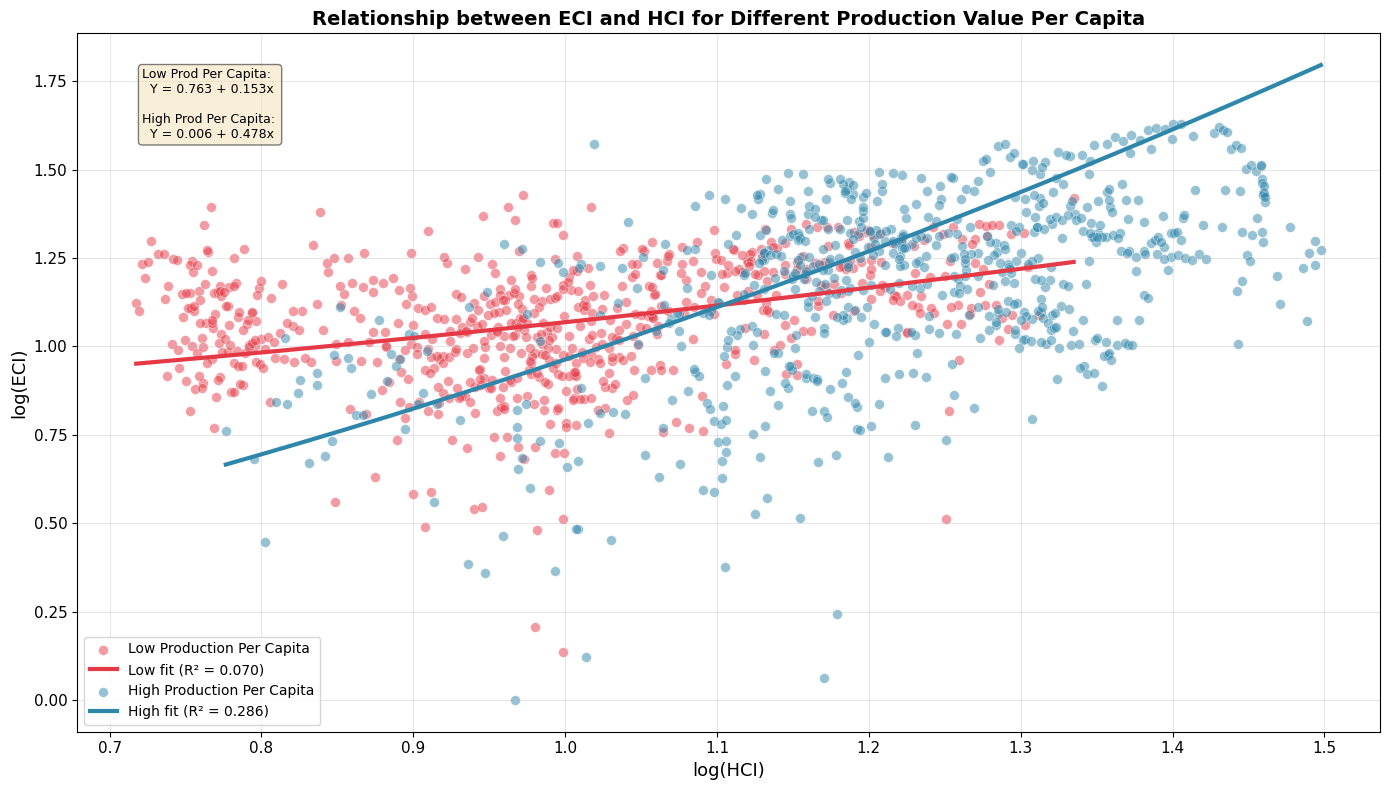


GROUP STATISTICS
\Median Production Per Capita threshold: 196.96
Low Production Per Capita observations: 675
High Production Per Capita observations: 675

LOW PRODUCTION PER CAPITA GROUP - QUADRATIC FIT

Equation: log(ECI) = 0.7630 + 0.1526

R-squared: 0.0696
Adjusted R-squared: 0.0682

Coefficients:
  Intercept: 0.7630 (p-value: 0.0000)
  Linear term: 0.1526 (p-value: 0.0000)

HIGH PRODUCTION PER CAPITA GROUP - QUADRATIC FIT

Equation: log(ECI) = 0.0058 + 0.4784

R-squared: 0.2859
Adjusted R-squared: 0.2848

Coefficients:
  Intercept: 0.0058 (p-value: 0.9354)
  Linear term: 0.4784 (p-value: 0.0000)

Linear term (slope at origin):
  Low Prod Per Capita:  0.1526
  High Prod Per Capita: 0.4784
  Difference: 0.3258


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Create dummy variable for high/low production per capita
median_prod_per_capita = high_resource_countries_df['Total_Production_Value_Per_Capita'].median()
high_resource_countries_df['High_Prod_Per_Capita'] = (
    high_resource_countries_df['Total_Production_Value_Per_Capita'] > median_prod_per_capita
).astype(int)


x = high_resource_countries_df['log_HCI'].values
y = high_resource_countries_df['log_ECI'].values
groups = high_resource_countries_df['High_Prod_Per_Capita'].values

# Remove any NaN values
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(groups)
x_clean = x[mask]
y_clean = y[mask]
groups_clean = groups[mask]

# Separate data by group
x_low = x_clean[groups_clean == 0]
y_low = y_clean[groups_clean == 0]
x_high = x_clean[groups_clean == 1]
y_high = y_clean[groups_clean == 1]

# Fit quadratic models for each group
def fit_line(x_data, y_data):
    x_squared = x_data
    X_quad = np.column_stack([x_data, x_squared])
    X_quad = sm.add_constant(X_quad)
    model = sm.OLS(y_data, X_quad)
    return model.fit()

results_low = fit_line(x_low, y_low)
results_high = fit_line(x_high, y_high)

# Generate smooth lines for plotting
x_range_low = np.linspace(x_low.min(), x_low.max(), 300)
x_range_high = np.linspace(x_high.min(), x_high.max(), 300)

def predict_line(x_range, results):
    x_range_squared = x_range ** 2
    X_range = np.column_stack([np.ones_like(x_range), x_range, x_range_squared])
    return results.predict(X_range)

y_pred_low = predict_line(x_range_low, results_low)
y_pred_high = predict_line(x_range_high, results_high)

# Create the plot
plt.figure(figsize=(14, 8))

# Plot low production per capita group
plt.scatter(x_low, y_low, alpha=0.5, s=50, color='#E63946', 
            edgecolors='white', linewidth=0.5, label='Low Production Per Capita')
plt.plot(x_range_low, y_pred_low, color='#E63946', linewidth=3, linestyle='-',
         label=f'Low fit (R² = {results_low.rsquared:.3f})')

# Plot high production per capita group
plt.scatter(x_high, y_high, alpha=0.5, s=50, color='#2E86AB', 
            edgecolors='white', linewidth=0.5, label='High Production Per Capita')
plt.plot(x_range_high, y_pred_high, color='#2E86AB', linewidth=3, linestyle='-',
         label=f'High fit (R² = {results_high.rsquared:.3f})')

plt.xlabel('log(HCI)', fontsize=13)
plt.ylabel('log(ECI)', fontsize=13)
plt.title('Relationship between ECI and HCI for Different Production Value Per Capita', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=11)

# Add equations text
low_intercept = results_low.params[0]
low_linear = results_low.params[1]

high_intercept = results_high.params[0]
high_linear = results_high.params[1]

equation_text = (
    f'Low Prod Per Capita:\n'
    f'  Y = {low_intercept:.3f} + {low_linear:.3f}x \n\n'
    f'High Prod Per Capita:\n'
    f'  Y = {high_intercept:.3f} + {high_linear:.3f}x'
)
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*80)
print("GROUP STATISTICS")
print("="*80)
print(f"\Median Production Per Capita threshold: {median_prod_per_capita:.2f}")
print(f"Low Production Per Capita observations: {len(x_low)}")
print(f"High Production Per Capita observations: {len(x_high)}")

print("\n" + "="*80)
print("LOW PRODUCTION PER CAPITA GROUP - QUADRATIC FIT")
print("="*80)
print(f"\nEquation: log(ECI) = {low_intercept:.4f} + {low_linear:.4f}")
print(f"\nR-squared: {results_low.rsquared:.4f}")
print(f"Adjusted R-squared: {results_low.rsquared_adj:.4f}")
print(f"\nCoefficients:")
print(f"  Intercept: {low_intercept:.4f} (p-value: {results_low.pvalues[0]:.4f})")
print(f"  Linear term: {low_linear:.4f} (p-value: {results_low.pvalues[1]:.4f})")

print("\n" + "="*80)
print("HIGH PRODUCTION PER CAPITA GROUP - QUADRATIC FIT")
print("="*80)
print(f"\nEquation: log(ECI) = {high_intercept:.4f} + {high_linear:.4f}")
print(f"\nR-squared: {results_high.rsquared:.4f}")
print(f"Adjusted R-squared: {results_high.rsquared_adj:.4f}")
print(f"\nCoefficients:")
print(f"  Intercept: {high_intercept:.4f} (p-value: {results_high.pvalues[0]:.4f})")
print(f"  Linear term: {high_linear:.4f} (p-value: {results_high.pvalues[1]:.4f})")


print("="*80)

# Display comparison

print(f"\nLinear term (slope at origin):")
print(f"  Low Prod Per Capita:  {low_linear:.4f}")
print(f"  High Prod Per Capita: {high_linear:.4f}")
print(f"  Difference: {high_linear - low_linear:.4f}")

print("="*80)

In [ ]:
import plotly.graph_objects as go
import numpy as np

# Create figure
fig = go.Figure()

# Add scatter plot for low production per capita group
fig.add_trace(go.Scatter(
    x=x_low,
    y=y_low,
    mode='markers',
    name='Low Production Per Capita',
    marker=dict(
        size=8,
        color='#E63946',
        opacity=0.5,
        line=dict(color='white', width=0.5)
    ),
    hovertemplate='<b>Low Prod Per Capita</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Add quadratic fit line for low production
fig.add_trace(go.Scatter(
    x=x_range_low,
    y=y_pred_low,
    mode='lines',
    name=f'Low fit (R² = {results_low.rsquared:.3f})',
    line=dict(color='#E63946', width=3),
    hovertemplate='<b>Low Fit</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'Predicted log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Add scatter plot for high production per capita group
fig.add_trace(go.Scatter(
    x=x_high,
    y=y_high,
    mode='markers',
    name='High Production Per Capita',
    marker=dict(
        size=8,
        color='#2E86AB',
        opacity=0.5,
        line=dict(color='white', width=0.5)
    ),
    hovertemplate='<b>High Prod Per Capita</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Add quadratic fit line for high production
fig.add_trace(go.Scatter(
    x=x_range_high,
    y=y_pred_high,
    mode='lines',
    name=f'High fit (R² = {results_high.rsquared:.3f})',
    line=dict(color='#2E86AB', width=3),
    hovertemplate='<b>High Fit</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'Predicted log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Update layout
fig.update_layout(
    title=dict(
        text='Relationship between ECI and HCI for Different Production Value Per Capita',
        font=dict(size=16, family='Arial, sans-serif', color='#333333')
    ),
    xaxis=dict(
        title=dict(
            text='log(HCI)',
            font=dict(size=14)
        ),
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128, 128, 128, 0.3)'
    ),
    yaxis=dict(
        title=dict(
            text='log(ECI)',
            font=dict(size=14)
        ),
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128, 128, 128, 0.3)'
    ),
    width=1000,
    height=600,
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='rgba(0, 0, 0, 0.2)',
        borderwidth=1
    )
)

# Export to HTML
fig.write_html(r'..\\figures\\summary_stats\\eci_hci_production_interaction.html')
print("Plot exported to 'eci_hci_production_interaction.html'")

# Optional: Show the plot
fig.show()

Plot exported to 'eci_hci_production_interaction.html'


## Model with only lagged variable

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np


# Create a clean dataset
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged log_ECI
regression_data['log_ECI_lag1'] = regression_data.groupby('Country Code')['log_ECI'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data = regression_data.dropna(subset=['log_ECI_lag1'])


# Define y and X (NO country dummies)
y = regression_data['log_ECI']
X = regression_data['log_ECI_lag1']

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_one_lag = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_one_lag.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged ECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_one_lag.params.index:
        coef = results_one_lag.params[var]
        se = results_one_lag.bse[var]
        tstat = results_one_lag.tvalues[var]
        pval = results_one_lag.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('_lag1', ' (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_one_lag.rsquared:.4f}")
print(f"Adjusted R-squared: {results_one_lag.rsquared_adj:.4f}")
print(f"N observations: {results_one_lag.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of lagged dependent variable
print("\n" + "="*80)
print("LAGGED DEPENDENT VARIABLE INTERPRETATION")
print("="*80)
if 'log_ECI_lag1' in results_one_lag.params.index:
    lag_coef = results_one_lag.params['log_ECI_lag1']
    lag_pval = results_one_lag.pvalues['log_ECI_lag1']
    print(f"log_ECI(t-1): {lag_coef:.4f} (p={lag_pval:.4f})")
    print(f"  → Persistence/autocorrelation in economic complexity")
    print(f"  → A 1% higher ECI last year predicts {lag_coef:.2%} higher ECI this year")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Log-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_one_lag.params.index:
    hci_int_coef = results_one_lag.params['log_HCI_x_log_Production']
    hci_int_pval = results_one_lag.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The elasticity of ECI with respect to HCI INCREASES with resource production")
        else:
            print("  → The elasticity of ECI with respect to HCI DECREASES with resource production")

if 'log_GFCF_x_log_Production' in results_one_lag.params.index:
    gcf_int_coef = results_one_lag.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_one_lag.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The elasticity of ECI with respect to investment INCREASES with resource production")
        else:
            print("  → The elasticity of ECI with respect to investment DECREASES with resource production")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     494.5
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.53e-28
Time:                        18:06:43   Log-Likelihood:                 876.66
No. Observations:                1296   AIC:                            -1749.
Df Residuals:                    1294   BIC:                            -1739.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1874      0.039      4.785   

 Adj. R-squared: 0.698. In model 3, Adj. R-squared is 0.712. Adj R-squared increased marginally. 

## No log variables (better for effect on ECI interpretation)

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset — using ECI (levels) instead of log_ECI
regression_data = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Mean-center the logged variables before creating interactions
regression_data['log_HCI_centered'] = regression_data['log_HCI'] - regression_data['log_HCI'].mean()
regression_data['log_GFCF_centered'] = regression_data['log_GFCF'] - regression_data['log_GFCF'].mean()
regression_data['log_Production_centered'] = regression_data['log_Production_Value'] - regression_data['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data['log_HCI_x_log_Production'] = regression_data['log_HCI_centered'] * regression_data['log_Production_centered']
regression_data['log_GFCF_x_log_Production'] = regression_data['log_GFCF_centered'] * regression_data['log_Production_centered']

# Add interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y (ECI in levels) and X
y = regression_data['Economic Complexity Index']
X = regression_data[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors by country
model = sm.OLS(y, X)
results_levels = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_levels.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_levels.params.index:
        coef = results_levels.params[var]
        se = results_levels.bse[var]
        tstat = results_levels.tvalues[var]
        pval = results_levels.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_levels.rsquared:.4f}")
print(f"Adjusted R-squared: {results_levels.rsquared_adj:.4f}")
print(f"N observations: {results_levels.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Level-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_levels.params.index:
    hci_int_coef = results_levels.params['log_HCI_x_log_Production']
    hci_int_pval = results_levels.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with HCI")
        else:
            print("  → The effect of resource production on ECI DECREASES with HCI")

if 'log_GFCF_x_log_Production' in results_levels.params.index:
    gcf_int_coef = results_levels.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_levels.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with investment")
        else:
            print("  → The effect of resource production on ECI DECREASES with investment")

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.360
Model:                                   OLS   Adj. R-squared:                  0.356
Method:                        Least Squares   F-statistic:                     8.504
Date:                       Sun, 22 Feb 2026   Prob (F-statistic):           2.34e-07
Time:                               18:16:19   Log-Likelihood:                -1073.2
No. Observations:                       1350   AIC:                             2164.
Df Residuals:                           1341   BIC:                             2211.
Df Model:                                  8                                         
Covariance Type:                     cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged Economic Complexity Index
regression_data['ECI_lag1'] = regression_data.groupby('Country Code')['Economic Complexity Index'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data = regression_data.dropna(subset=['ECI_lag1'])

# Mean-center the logged variables before creating interactions
regression_data['log_HCI_centered'] = regression_data['log_HCI'] - regression_data['log_HCI'].mean()
regression_data['log_GFCF_centered'] = regression_data['log_GFCF'] - regression_data['log_GFCF'].mean()
regression_data['log_Production_centered'] = regression_data['log_Production_Value'] - regression_data['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data['log_HCI_x_log_Production'] = regression_data['log_HCI_centered'] * regression_data['log_Production_centered']
regression_data['log_GFCF_x_log_Production'] = regression_data['log_GFCF_centered'] * regression_data['log_Production_centered']

# Add lagged ECI and interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'ECI_lag1',
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y and X (NO country dummies)
y = regression_data['Economic Complexity Index']
X = regression_data[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_one_lag = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_one_lag.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged ECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_one_lag.params.index:
        coef = results_one_lag.params[var]
        se = results_one_lag.bse[var]
        tstat = results_one_lag.tvalues[var]
        pval = results_one_lag.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('ECI_lag1', 'Economic Complexity Index (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_one_lag.rsquared:.4f}")
print(f"Adjusted R-squared: {results_one_lag.rsquared_adj:.4f}")
print(f"N observations: {results_one_lag.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of lagged dependent variable
print("\n" + "="*80)
print("LAGGED DEPENDENT VARIABLE INTERPRETATION")
print("="*80)
if 'ECI_lag1' in results_one_lag.params.index:
    lag_coef = results_one_lag.params['ECI_lag1']
    lag_pval = results_one_lag.pvalues['ECI_lag1']
    print(f"Economic Complexity Index (t-1): {lag_coef:.4f} (p={lag_pval:.4f})")
    print(f"  → Persistence/autocorrelation in economic complexity")
    print(f"  → A 1-unit higher ECI last year predicts a {lag_coef:.4f} higher ECI this year")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Level-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_one_lag.params.index:
    hci_int_coef = results_one_lag.params['log_HCI_x_log_Production']
    hci_int_pval = results_one_lag.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with HCI")
        else:
            print("  → The effect of resource production on ECI DECREASES with HCI")

if 'log_GFCF_x_log_Production' in results_one_lag.params.index:
    gcf_int_coef = results_one_lag.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_one_lag.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with investment")
        else:
            print("  → The effect of resource production on ECI DECREASES with investment")

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.780
Model:                                   OLS   Adj. R-squared:                  0.778
Method:                        Least Squares   F-statistic:                     360.4
Date:                       Sun, 22 Feb 2026   Prob (F-statistic):           3.01e-44
Time:                               18:24:13   Log-Likelihood:                -339.19
No. Observations:                       1296   AIC:                             698.4
Df Residuals:                           1286   BIC:                             750.0
Df Model:                                  9                                         
Covariance Type:                     cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged Economic Complexity Index
regression_data['ECI_lag1'] = regression_data.groupby('Country Code')['Economic Complexity Index'].shift(1)

# Create lagged versions of all independent variables
lagged_vars = []
for var in independent_vars:
    lagged_name = f'{var}_lag1'
    regression_data[lagged_name] = regression_data.groupby('Country Code')[var].shift(1)
    lagged_vars.append(lagged_name)

# Add lagged ECI to the list
lagged_vars_with_eci = lagged_vars + ['ECI_lag1']

# Drop rows where any lagged variable is missing (first year for each country)
regression_data = regression_data.dropna(subset=lagged_vars_with_eci)

# Mean-center the LAGGED logged variables before creating interactions
regression_data['log_HCI_lag1_centered'] = regression_data['log_HCI_lag1'] - regression_data['log_HCI_lag1'].mean()
regression_data['log_GFCF_lag1_centered'] = regression_data['log_GFCF_lag1'] - regression_data['log_GFCF_lag1'].mean()
regression_data['log_Production_lag1_centered'] = regression_data['log_Production_Value_lag1'] - regression_data['log_Production_Value_lag1'].mean()

# Create interaction terms from centered LAGGED variables
regression_data['log_HCI_x_log_Production_lag1'] = regression_data['log_HCI_lag1_centered'] * regression_data['log_Production_lag1_centered']
regression_data['log_GFCF_x_log_Production_lag1'] = regression_data['log_GFCF_lag1_centered'] * regression_data['log_Production_lag1_centered']

# Add interaction terms to lagged variables list
lagged_vars_with_interactions = lagged_vars_with_eci + [
    'log_HCI_x_log_Production_lag1',
    'log_GFCF_x_log_Production_lag1'
]

# Define y and X
y = regression_data['Economic Complexity Index']
X = regression_data[lagged_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_lags = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_lags.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (All Lagged, Clustered SE by Country)")
print("="*80)
for var in lagged_vars_with_interactions + ['const']:
    if var in results_lags.params.index:
        coef = results_lags.params[var]
        se = results_lags.bse[var]
        tstat = results_lags.tvalues[var]
        pval = results_lags.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('ECI_lag1', 'Economic Complexity Index (t-1)').replace('_lag1', ' (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_lags.rsquared:.4f}")
print(f"Adjusted R-squared: {results_lags.rsquared_adj:.4f}")
print(f"N observations: {results_lags.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation
print("\n" + "="*80)
print("MODEL INTERPRETATION")
print("="*80)
print("All independent variables are lagged by one period (t-1)")
print("This specification helps address:")
print("  - Endogeneity concerns (X(t-1) predetermined relative to Y(t))")
print("  - Reverse causality (past values can't be caused by current outcomes)")
print("  - Dynamic effects (how past conditions influence current complexity)")

if 'ECI_lag1' in results_lags.params.index:
    lag_coef = results_lags.params['ECI_lag1']
    print(f"\nPersistence coefficient: {lag_coef:.4f}")
    print(f"  → A 1-unit higher ECI last year predicts a {lag_coef:.4f} higher ECI this year")

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.779
Model:                                   OLS   Adj. R-squared:                  0.778
Method:                        Least Squares   F-statistic:                     326.7
Date:                       Sun, 22 Feb 2026   Prob (F-statistic):           3.87e-43
Time:                               18:30:42   Log-Likelihood:                -341.23
No. Observations:                       1296   AIC:                             702.5
Df Residuals:                           1286   BIC:                             754.1
Df Model:                                  9                                         
Covariance Type:                     cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

## Correlation ECI manufacturing value added

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
corr_data = high_resource_countries_df[['Economic Complexity Index', 'Manufacturing', 'Country Code', 'Year']].copy()
corr_data['Economic Complexity Index'] = pd.to_numeric(corr_data['Economic Complexity Index'], errors='coerce')
corr_data['Manufacturing'] = pd.to_numeric(corr_data['Manufacturing'], errors='coerce')
corr_data = corr_data.dropna(subset=['Economic Complexity Index', 'Manufacturing'])

# --- Summary statistics ---
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(corr_data[['Economic Complexity Index', 'Manufacturing']].describe().round(4))

# --- Correlation coefficients ---
pearson_r, pearson_p = stats.pearsonr(corr_data['Economic Complexity Index'], corr_data['Manufacturing'])
spearman_r, spearman_p = stats.spearmanr(corr_data['Economic Complexity Index'], corr_data['Manufacturing'])

print("\n" + "="*60)
print("CORRELATION RESULTS")
print("="*60)
print(f"Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.4f}{'***' if pearson_p < 0.01 else '**' if pearson_p < 0.05 else '*' if pearson_p < 0.10 else ''})")
print(f"Spearman ρ = {spearman_r:.4f}  (p = {spearman_p:.4f}{'***' if spearman_p < 0.01 else '**' if spearman_p < 0.05 else '*' if spearman_p < 0.10 else ''})")
print(f"\nN observations : {len(corr_data)}")
print(f"N countries    : {corr_data['Country Code'].nunique()}")

SUMMARY STATISTICS
       Economic Complexity Index  Manufacturing
count                  1350.0000      1350.0000
mean                     -0.7600        11.4560
std                       0.6698         6.0741
min                      -2.8900         0.6522
25%                      -1.2197         7.4579
50%                      -0.8035        10.2082
75%                      -0.3430        14.8802
max                       1.2110        44.9804

CORRELATION RESULTS
Pearson  r = 0.3271  (p = 0.0000***)
Spearman ρ = 0.3232  (p = 0.0000***)

N observations : 1350
N countries    : 54


## Add Technology, Population and resource type controls (only used access to electricity because of high correlation). In resource type dummies the base is precious metals dominant

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)',
    # Resource type dummies
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    # Additional controls
    'Access to electricity (% of population)',
    #'Mobile cellular subscriptions (per 100 people)',
    #'Urban population (% of total population)',
    #'Population'
]

# Create a clean dataset
regression_data = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Log-transform Population (scale adjustment)
#regression_data['log_Population'] = np.log(regression_data['Population'])
#regression_data = regression_data.drop(columns=['Population'])

# Update independent_vars to reflect the transformation
#independent_vars = [v for v in independent_vars if v != 'Population'] + ['log_Population']

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged Economic Complexity Index
regression_data['ECI_lag1'] = regression_data.groupby('Country Code')['Economic Complexity Index'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data = regression_data.dropna(subset=['ECI_lag1'])

# Mean-center the logged variables before creating interactions
regression_data['log_HCI_centered'] = regression_data['log_HCI'] - regression_data['log_HCI'].mean()
regression_data['log_GFCF_centered'] = regression_data['log_GFCF'] - regression_data['log_GFCF'].mean()
regression_data['log_Production_centered'] = regression_data['log_Production_Value'] - regression_data['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data['log_HCI_x_log_Production'] = regression_data['log_HCI_centered'] * regression_data['log_Production_centered']
regression_data['log_GFCF_x_log_Production'] = regression_data['log_GFCF_centered'] * regression_data['log_Production_centered']

# Add lagged ECI and interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'ECI_lag1',
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y and X (NO country dummies)
y = regression_data['Economic Complexity Index']
X = regression_data[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_one_lag = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_one_lag.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged ECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_one_lag.params.index:
        coef = results_one_lag.params[var]
        se = results_one_lag.bse[var]
        tstat = results_one_lag.tvalues[var]
        pval = results_one_lag.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('ECI_lag1', 'Economic Complexity Index (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_one_lag.rsquared:.4f}")
print(f"Adjusted R-squared: {results_one_lag.rsquared_adj:.4f}")
print(f"N observations: {results_one_lag.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of lagged dependent variable
print("\n" + "="*80)
print("LAGGED DEPENDENT VARIABLE INTERPRETATION")
print("="*80)
if 'ECI_lag1' in results_one_lag.params.index:
    lag_coef = results_one_lag.params['ECI_lag1']
    lag_pval = results_one_lag.pvalues['ECI_lag1']
    print(f"Economic Complexity Index (t-1): {lag_coef:.4f} (p={lag_pval:.4f})")
    print(f"  → Persistence/autocorrelation in economic complexity")
    print(f"  → A 1-unit higher ECI last year predicts a {lag_coef:.4f} higher ECI this year")

# Interpretation of resource type dummies
print("\n" + "="*80)
print("RESOURCE TYPE DUMMIES INTERPRETATION")
print("="*80)
for dummy in ['Hydrocarbons_Dominant', 'Subsoil_Metals_Dominant', 'Precious_Metals_Dominant']:
    if dummy in results_one_lag.params.index:
        coef = results_one_lag.params[dummy]
        pval = results_one_lag.pvalues[dummy]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else '(not significant)'
        print(f"{dummy}: {coef:.4f} (p={pval:.4f}) {sig}")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Level-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_one_lag.params.index:
    hci_int_coef = results_one_lag.params['log_HCI_x_log_Production']
    hci_int_pval = results_one_lag.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with HCI")
        else:
            print("  → The effect of resource production on ECI DECREASES with HCI")

if 'log_GFCF_x_log_Production' in results_one_lag.params.index:
    gcf_int_coef = results_one_lag.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_one_lag.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with investment")
        else:
            print("  → The effect of resource production on ECI DECREASES with investment")
            

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.783
Model:                                   OLS   Adj. R-squared:                  0.781
Method:                        Least Squares   F-statistic:                     259.5
Date:                       Sun, 22 Feb 2026   Prob (F-statistic):           1.44e-42
Time:                               19:05:30   Log-Likelihood:                -328.26
No. Observations:                       1296   AIC:                             682.5
Df Residuals:                           1283   BIC:                             749.7
Df Model:                                 12                                         
Covariance Type:                     cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

Access to electricity is a main drive. Intrestingly, GFCF is now signifiant and HCI is not. Subsoil metals perform worse among the 3 type of resources

In [ ]:
import pandas as pd
import numpy as np

def format_coef(coef, pval):
    """Format coefficient with significance stars."""
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    return f"{coef:.3f}<sup>{stars}</sup>"

def format_se(se):
    return f"({se:.3f})"

# --- Variable display names (order matters for table rows) ---
var_labels = {
    'log_HCI':                                    'Human Capital Index (log)',
    'log_GFCF':                                   'Gross Fixed Capital Formation (log)',
    'log_Production_Value':                       'Production Value (log)',
    'Political stability — estimate':             'Political Stability',
    'Rule of law index':                          'Rule of Law',
    'Trade (% of GDP)':                           'Trade Openness (% GDP)',
    'Hydrocarbons_Dominant':                      'Hydrocarbons Dominant',
    'Subsoil_Metals_Dominant':                    'Subsoil Metals Dominant',
    'Access to electricity (% of population)':   'Access to Electricity (%)',
    'log_HCI_x_log_Production':                   'HCI × Production (log)',
    'log_GFCF_x_log_Production':                  'GFCF × Production (log)',
    'ECI_lag1':                                   'Economic Complexity Index (t-1)',
}

# --- Extract results from your model ---
# Replace `results_one_lag` with whichever model object you want to export
model = results_one_lag
params  = model.params
bse     = model.bse
pvalues = model.pvalues

# --- Build rows ---
rows_html = ""
for var, label in var_labels.items():
    if var not in params.index:
        continue
    coef_str = format_coef(params[var], pvalues[var])
    se_str   = format_se(bse[var])
    rows_html += f"""
        <tr>
            <td class="varname">{label}</td>
            <td class="num">{coef_str}</td>
        </tr>
        <tr class="se-row">
            <td></td>
            <td class="num">{se_str}</td>
        </tr>"""

# --- Model fit stats ---
n_obs      = int(model.nobs)
n_countries = regression_data['Country Code'].nunique()
r2         = model.rsquared
r2_adj     = model.rsquared_adj
resid_std  = np.sqrt(model.mse_resid)
df_resid   = int(model.df_resid)
fstat      = model.fvalue
fstat_p    = model.f_pvalue
fstat_sig  = '***' if fstat_p < 0.01 else '**' if fstat_p < 0.05 else '*' if fstat_p < 0.10 else ''
df_model   = int(model.df_model)

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<style>
  body {{ font-family: "Times New Roman", Times, serif; font-size: 13px; margin: 40px; color: #000; }}
  h2 {{ font-size: 14px; font-weight: normal; text-align: center; margin-bottom: 4px; }}
  table {{ border-collapse: collapse; width: 480px; margin: 0 auto; }}
  th, td {{ padding: 3px 10px; text-align: center; }}
  td.varname {{ text-align: left; padding-left: 4px; }}
  tr.se-row td {{ padding-top: 0px; padding-bottom: 4px; color: #000; }}
  .num {{ text-align: center; }}
  .top-border {{ border-top: 2px solid #000; }}
  .mid-border {{ border-top: 1px solid #000; }}
  .bot-border {{ border-bottom: 2px solid #000; }}
  .note {{ font-size: 11px; text-align: left; width: 480px; margin: 4px auto 0; }}
  sup {{ font-size: 9px; }}
</style>
</head>
<body>

<h2>Economic Complexity in Resource-Rich Countries</h2>

<table>
  <thead>
    <tr class="top-border">
      <th></th>
      <th colspan="1"><em>Dependent variable: Economic Complexity Index</em></th>
    </tr>
    <tr class="mid-border bot-border">
      <th></th>
      <th>(1)</th>
    </tr>
  </thead>
  <tbody>
    {rows_html}
    <tr class="mid-border">
      <td class="varname">Observations</td>
      <td class="num">{n_obs}</td>
    </tr>
    <tr>
      <td class="varname">Countries</td>
      <td class="num">{n_countries}</td>
    </tr>
    <tr>
      <td class="varname">R<sup>2</sup></td>
      <td class="num">{r2:.3f}</td>
    </tr>
    <tr>
      <td class="varname">Adjusted R<sup>2</sup></td>
      <td class="num">{r2_adj:.3f}</td>
    </tr>
    <tr>
      <td class="varname">Residual Std. Error</td>
      <td class="num">{resid_std:.3f} (df={df_resid})</td>
    </tr>
    <tr>
      <td class="varname">F Statistic</td>
      <td class="num">{fstat:.3f}<sup>{fstat_sig}</sup> (df={df_model}; {df_resid})</td>
    </tr>
    <tr>
      <td class="varname">Clustered SE</td>
      <td class="num">Country</td>
    </tr>
    <tr>
      <td class="varname">Interaction Terms</td>
      <td class="num">Yes</td>
    </tr>
    <tr class="bot-border">
      <td class="varname">Lagged Dependent Variable</td>
      <td class="num">Yes</td>
    </tr>
  </tbody>
</table>

<p class="note"><em>Note:</em> &nbsp; <sup>*</sup>p&lt;0.1; &nbsp;<sup>**</sup>p&lt;0.05; &nbsp;<sup>***</sup>p&lt;0.01</p>

</body>
</html>
"""

# --- Save to file ---
output_path = "additional_controls_regression_table.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"Table saved to: {output_path}")

Table saved to: additional_controls_regression_table.html


# Appendix

## GDP as output variable as a robustness check

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Create interaction terms
high_resource_countries_df['HCI_x_ResourceProduction'] = (
    high_resource_countries_df['Human capital index'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

high_resource_countries_df['GrossCapForm_x_ResourceProduction'] = (
    high_resource_countries_df['Gross fixed capital formation, all, Constant prices, Percent of GDP'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

# Define independent variables
independent_vars = [
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political corruption index',
    'Political stability — estimate',
    'Rule of law index',
    'Property rights',
    'Economic Complexity Index',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'HCI_x_ResourceProduction',
    'GrossCapForm_x_ResourceProduction'
]

# Create a clean dataset - IMPORTANT: include Cluster variable
regression_data = high_resource_countries_df[['GDP per capita (constant prices, PPP)', 'Country Code', 'Cluster'] + independent_vars].copy()

# Convert all independent variables to numeric (just in case)
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Define y and X from clean data
y = regression_data['GDP per capita (constant prices, PPP)']
X = regression_data[independent_vars]

# Get cluster variable
clusters = regression_data['Cluster']

# Create country dummies from clean data
country_dummies = pd.get_dummies(regression_data['Country Code'], prefix='Country', drop_first=True)

# Ensure country dummies are numeric (they should be, but just in case)
country_dummies = country_dummies.astype(float)

# Combine X with country dummies
X = X.join(country_dummies)

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors
model = sm.OLS(y, X)
results = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# Display results
print(results.summary())

# Display main variables
print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Clustered SE)")
print("="*80)
main_vars = independent_vars + ['const']
for var in main_vars:
    if var in results.params.index:
        coef = results.params[var]
        se = results.bse[var]
        tstat = results.tvalues[var]
        pval = results.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations: {results.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"N clusters: {clusters.nunique()}")

                                      OLS Regression Results                                     
Dep. Variable:     GDP per capita (constant prices, PPP)   R-squared:                       0.971
Model:                                               OLS   Adj. R-squared:                  0.969
Method:                                    Least Squares   F-statistic:                     13.61
Date:                                   Sun, 25 Jan 2026   Prob (F-statistic):             0.0298
Time:                                           21:16:37   Log-Likelihood:                -12416.
No. Observations:                                   1300   AIC:                         2.496e+04
Df Residuals:                                       1237   BIC:                         2.528e+04
Df Model:                                             62                                         
Covariance Type:                                 cluster                                         
                    

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 62, but rank is 3



When using GDP as output Gross Cap formation x Resource production, and HCI are significant.

## Add year fixed effects

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Create interaction terms
high_resource_countries_df['HCI_x_ResourceProduction'] = (
    high_resource_countries_df['Human capital index'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

high_resource_countries_df['GrossCapForm_x_ResourceProduction'] = (
    high_resource_countries_df['Gross fixed capital formation, all, Constant prices, Percent of GDP'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

# Define independent variables
independent_vars = [
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political corruption index',
    'Political stability — estimate',
    'Rule of law index',
    'Property rights',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'HCI_x_ResourceProduction',
    'GrossCapForm_x_ResourceProduction'
]

# Create a clean dataset - IMPORTANT: include Cluster and Year variables
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year', 'Cluster'] + independent_vars].copy()

# Convert all independent variables to numeric (just in case)
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Define y and X from clean data
y = regression_data['log_ECI']
X = regression_data[independent_vars]

# Get cluster variable
clusters = regression_data['Cluster']

# Create country dummies from clean data
country_dummies = pd.get_dummies(regression_data['Country Code'], prefix='Country', drop_first=True).astype(float)

# Create year dummies from clean data
year_dummies = pd.get_dummies(regression_data['Year'], prefix='Year', drop_first=True).astype(float)

# Combine X with country and year dummies (two-way fixed effects)
X = X.join(country_dummies).join(year_dummies)

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors
model = sm.OLS(y, X)
results = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# Display results
print(results.summary())

# Display main variables
print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Two-Way FE, Clustered SE)")
print("="*80)
main_vars = independent_vars + ['const']
for var in main_vars:
    if var in results.params.index:
        coef = results.params[var]
        se = results.bse[var]
        tstat = results.tvalues[var]
        pval = results.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations: {results.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"N years: {regression_data['Year'].nunique()}")
print(f"N clusters: {clusters.nunique()}")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                -2.125e+13
Date:                Sun, 25 Jan 2026   Prob (F-statistic):               1.00
Time:                        21:16:37   Log-Likelihood:                 935.84
No. Observations:                1300   AIC:                            -1700.
Df Residuals:                    1214   BIC:                            -1255.
Df Model:                          85                                         
Covariance Type:              cluster                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 85, but rank is 3



## Lagged Variable

In [ ]:
# Sort data by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged ECI (t-1)
regression_data['ECI_lag1'] = regression_data.groupby('Country Code')['log_ECI'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data = regression_data.dropna(subset=['ECI_lag1'])

# Get cluster variable (do this after dropping NAs)
clusters = regression_data['Cluster']

# Add lagged ECI to independent variables list
independent_vars_lagged = independent_vars + ['ECI_lag1']

# Define y and X from updated data
y = regression_data['log_ECI']
X = regression_data[independent_vars_lagged]

# Create country dummies only (no year dummies)
country_dummies = pd.get_dummies(regression_data['Country Code'], prefix='Country', drop_first=True).astype(float)

# Combine X with country fixed effects only
X_country_fe = X.join(country_dummies)

# Add constant
X_country_fe = sm.add_constant(X_country_fe)

# Run OLS with country fixed effects and clustered standard errors
model = sm.OLS(y, X_country_fe)
results = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

print(results.summary())

# Display main variables
print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Country FE with Lagged ECI, Clustered SE)")
print("="*80)
main_vars = independent_vars_lagged + ['const']
for var in main_vars:
    if var in results.params.index:
        coef = results.params[var]
        se = results.bse[var]
        tstat = results.tvalues[var]
        pval = results.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations: {results.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"N years: {regression_data['Year'].nunique()}")
print(f"N clusters: {clusters.nunique()}")

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 62, but rank is 3



                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     12.63
Date:                Sun, 25 Jan 2026   Prob (F-statistic):             0.0330
Time:                        21:16:38   Log-Likelihood:                 1011.4
No. Observations:                1248   AIC:                            -1897.
Df Residuals:                    1185   BIC:                            -1574.
Df Model:                          62                                         
Covariance Type:              cluster                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

## Add structural controls (electricity, urban population, death rates, type of resource)

In [ ]:
# Create interaction terms in original dataframe first
high_resource_countries_df['HCI_x_ResourceRents'] = (
    high_resource_countries_df['Human capital index'] * 
    high_resource_countries_df['Total natural resources rents (% of GDP)']
)

high_resource_countries_df['GrossCapForm_x_ResourceRents'] = (
    high_resource_countries_df['Gross fixed capital formation, all, Constant prices, Percent of GDP'] * 
    high_resource_countries_df['Total natural resources rents (% of GDP)']
)

# Define ALL variables we need (including Cluster)
all_vars = [
    'log_ECI',
    'Country Code',
    'Year',
    'Cluster',
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political corruption index',
    'Political stability — estimate',
    'Rule of law index',
    'Property rights',
    'GDP per capita (constant prices, PPP)',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'HCI_x_ResourceProduction',
    'GrossCapForm_x_ResourceProduction',
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    'Urban population (% of total population)',
    'Landlocked',
    'Access to electricity (% of population)',
    'Death rates, crude per 1000 people'
]

# Create clean regression dataset with all variables
regression_data = high_resource_countries_df[all_vars].copy()

# Convert numeric variables to numeric
numeric_vars = [v for v in all_vars if v not in ['Country Code']]
for var in numeric_vars:
    if var != 'Year':
        regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop missing values
regression_data = regression_data.dropna()

# Sort by country and year
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged ECI
regression_data['ECI_lag1'] = regression_data.groupby('Country Code')['log_ECI'].shift(1)

# Drop rows where lagged ECI is missing
regression_data = regression_data.dropna(subset=['ECI_lag1'])

# Get cluster variable
clusters = regression_data['Cluster']

# Define independent variables
independent_vars_expanded = [
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political corruption index',
    'Political stability — estimate',
    'Rule of law index',
    'Property rights',
    'GDP per capita (constant prices, PPP)',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'HCI_x_ResourceProduction',
    'GrossCapForm_x_ResourceProduction',
    'ECI_lag1',
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    'Urban population (% of total population)',
    'Landlocked',
    'Access to electricity (% of population)',
    'Death rates, crude per 1000 people'
]

# Define y and X
y = regression_data['log_ECI']
X = regression_data[independent_vars_expanded]

# Create country dummies only (no year dummies)
country_dummies = pd.get_dummies(regression_data['Country Code'], prefix='Country', drop_first=True).astype(float)

# Combine X with country fixed effects only
X_country_fe = X.join(country_dummies)

# Add constant
X_country_fe = sm.add_constant(X_country_fe)

# Run OLS with country fixed effects and clustered standard errors
model = sm.OLS(y, X_country_fe)
results = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

print(results.summary())

# Display main variables
print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Country FE with Lagged ECI, Clustered SE)")
print("="*80)
main_vars = independent_vars_expanded + ['const']
for var in main_vars:
    if var in results.params.index:
        coef = results.params[var]
        se = results.bse[var]
        tstat = results.tvalues[var]
        pval = results.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations: {results.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"N years: {regression_data['Year'].nunique()}")
print(f"N clusters: {clusters.nunique()}")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                -4.036e+10
Date:                Sun, 25 Jan 2026   Prob (F-statistic):               1.00
Time:                        21:21:16   Log-Likelihood:                 1024.7
No. Observations:                1248   AIC:                            -1909.
Df Residuals:                    1178   BIC:                            -1550.
Df Model:                          69                                         
Covariance Type:              cluster                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 70, but rank is 3



## All lagged variables

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Create interaction terms (we'll lag these after creating them)
high_resource_countries_df['HCI_x_ResourceProduction'] = (
    high_resource_countries_df['Human capital index'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

high_resource_countries_df['GrossCapForm_x_ResourceProduction'] = (
    high_resource_countries_df['Gross fixed capital formation, all, Constant prices, Percent of GDP'] * 
    high_resource_countries_df['Total_Production_Value_Per_Capita']
)

# Define independent variables
independent_vars = [
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political corruption index',
    'Political stability — estimate',
    'Rule of law index',
    'Property rights',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'HCI_x_ResourceProduction',
    'GrossCapForm_x_ResourceProduction'
]

# Create a clean dataset - IMPORTANT: include Cluster and Year
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year', 'Cluster'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged versions of all independent variables
lagged_vars = []
for var in independent_vars:
    lagged_name = f'{var}_lag1'
    regression_data[lagged_name] = regression_data.groupby('Country Code')[var].shift(1)
    lagged_vars.append(lagged_name)

# Drop rows where any lagged variable is missing (first year for each country)
regression_data = regression_data.dropna(subset=lagged_vars)

# Define y and X with lagged variables
y = regression_data['log_ECI']
X = regression_data[lagged_vars]

# Get cluster variable
clusters = regression_data['Cluster']

# Create country dummies from clean data
country_dummies = pd.get_dummies(regression_data['Country Code'], prefix='Country', drop_first=True).astype(float)

# Combine X with country dummies
X = X.join(country_dummies)

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors
model = sm.OLS(y, X)
results = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# Display results
print(results.summary())

# Display main variables
print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged, Country FE, Clustered SE)")
print("="*80)
main_vars = lagged_vars + ['const']
for var in main_vars:
    if var in results.params.index:
        coef = results.params[var]
        se = results.bse[var]
        tstat = results.tvalues[var]
        pval = results.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        # Clean up the variable name for display (remove _lag1)
        display_name = var.replace('_lag1', ' (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations: {results.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"N clusters: {clusters.nunique()}")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     5.438
Date:                Mon, 26 Jan 2026   Prob (F-statistic):             0.0989
Time:                        14:10:14   Log-Likelihood:                 889.72
No. Observations:                1248   AIC:                            -1655.
Df Residuals:                    1186   BIC:                            -1337.
Df Model:                          61                                         
Covariance Type:              cluster                                         
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 61, but rank is 3



In [ ]:
for var in independent_vars:
    within_variation = regression_data.groupby('Country Code')[var].nunique()
    if (within_variation == 1).all():
        print(f"{var}: Time-invariant (will be dropped with country FE)")
    else:
        print(f"{var}: Varies within countries (OK)")

Human capital index: Varies within countries (OK)
Gross fixed capital formation, all, Constant prices, Percent of GDP: Varies within countries (OK)
Political corruption index: Varies within countries (OK)
Political stability — estimate: Varies within countries (OK)
Rule of law index: Varies within countries (OK)
Property rights: Varies within countries (OK)
Total_Production_Value_Per_Capita: Varies within countries (OK)
Trade (% of GDP): Varies within countries (OK)
HCI_x_ResourceProduction: Varies within countries (OK)
GrossCapForm_x_ResourceProduction: Varies within countries (OK)
